In [156]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost 
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, 
    roc_curve, precision_recall_curve, make_scorer,RocCurveDisplay
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [157]:

df = pd.read_csv('Dataset/data_merged.csv')



In [158]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000



# 1. Variable binaria (popular vs no popular)
# la mediana como punto de corte
popularity_median = df_processed['popularity'].median()
print(f"   - Mediana de popularidad: {popularity_median}")
df_processed['is_popular_binary'] = (df_processed['popularity'] > popularity_median).astype(int)

# 2. Variable multiclase (3 niveles: Baja, Media, Alta)
# Usar terciles para dividir en 3 categorías
terciles = df_processed['popularity'].quantile([0.33, 0.67])
print(f"   - Terciles de popularidad: {terciles.values}")

def categorize_popularity(popularity):
    if popularity <= terciles[0.33]:
        return 0  # Baja
    elif popularity <= terciles[0.67]:
        return 1  # Media
    else:
        return 2  # Alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)

# 3. Variable multiclase (5 niveles: Muy Baja, Baja, Media, Alta, Muy Alta)
quintiles = df_processed['popularity'].quantile([0.2, 0.4, 0.6, 0.8])
print(f"   - Quintiles de popularidad: {quintiles.values}")

def categorize_popularity_5levels(popularity):
    if popularity <= quintiles[0.2]:
        return 0  # Muy Baja
    elif popularity <= quintiles[0.4]:
        return 1  # Baja
    elif popularity <= quintiles[0.6]:
        return 2  # Media
    elif popularity <= quintiles[0.8]:
        return 3  # Alta
    else:
        return 4  # Muy Alta

df_processed['popularity_5levels'] = df_processed['popularity'].apply(categorize_popularity_5levels)

print("Variable binaria (is_popular_binary):")
print(df_processed['is_popular_binary'].value_counts().sort_index())
print(f"   Proporción: {df_processed['is_popular_binary'].mean():.3f}")

print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print("\nVariable multiclase 5 niveles (popularity_5levels):")
fiveclass_counts = df_processed['popularity_5levels'].value_counts().sort_index()
fiveclass_labels = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
for i, (count, label) in enumerate(zip(fiveclass_counts, fiveclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print(f"\n✅ Preprocesamiento completado")
print(f"📊 Dataset final: {df_processed.shape[0]} filas, {df_processed.shape[1]} columnas")

   - Mediana de popularidad: 26.0
   - Terciles de popularidad: [ 9. 37.]
   - Quintiles de popularidad: [ 0. 17. 32. 46.]
Variable binaria (is_popular_binary):
is_popular_binary
0    88034
1    84196
Name: count, dtype: int64
   Proporción: 0.489

Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 57080 (33.1%)
   1 (Media): 60091 (34.9%)
   2 (Alta): 55059 (32.0%)

Variable multiclase 5 niveles (popularity_5levels):
   0 (Muy Baja): 39729 (23.1%)
   1 (Baja): 29179 (16.9%)
   2 (Media): 34591 (20.1%)
   3 (Alta): 34303 (19.9%)
   4 (Muy Alta): 34428 (20.0%)

✅ Preprocesamiento completado
📊 Dataset final: 172230 filas, 75 columnas


<Axes: xlabel='popularity_5levels'>

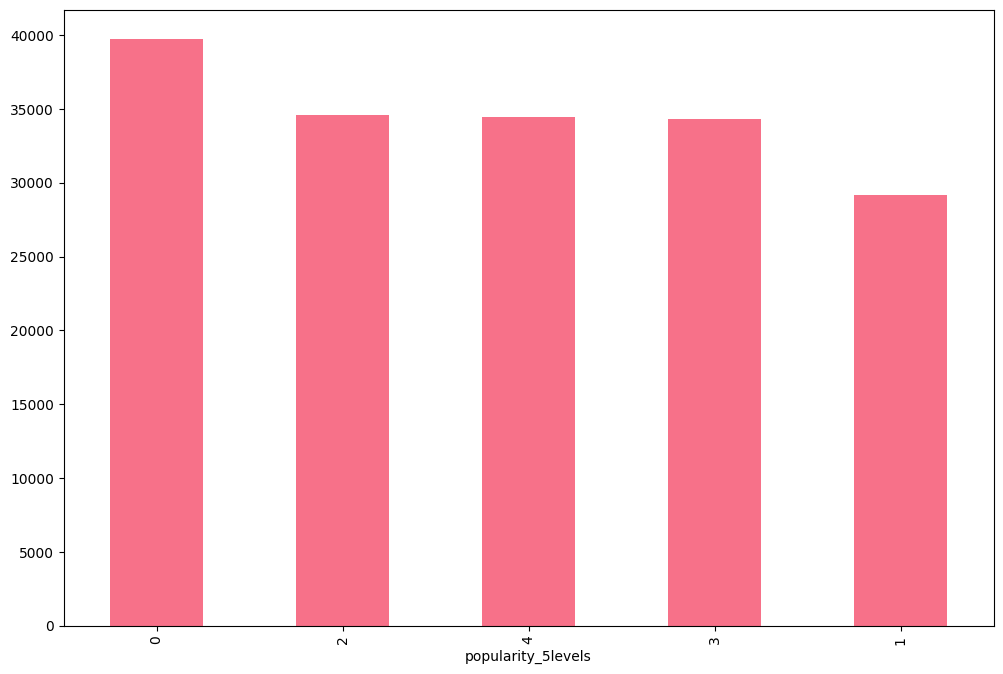

In [159]:
df_processed['popularity_5levels'].value_counts().plot(kind='bar')

<Axes: xlabel='popularity_multiclass'>

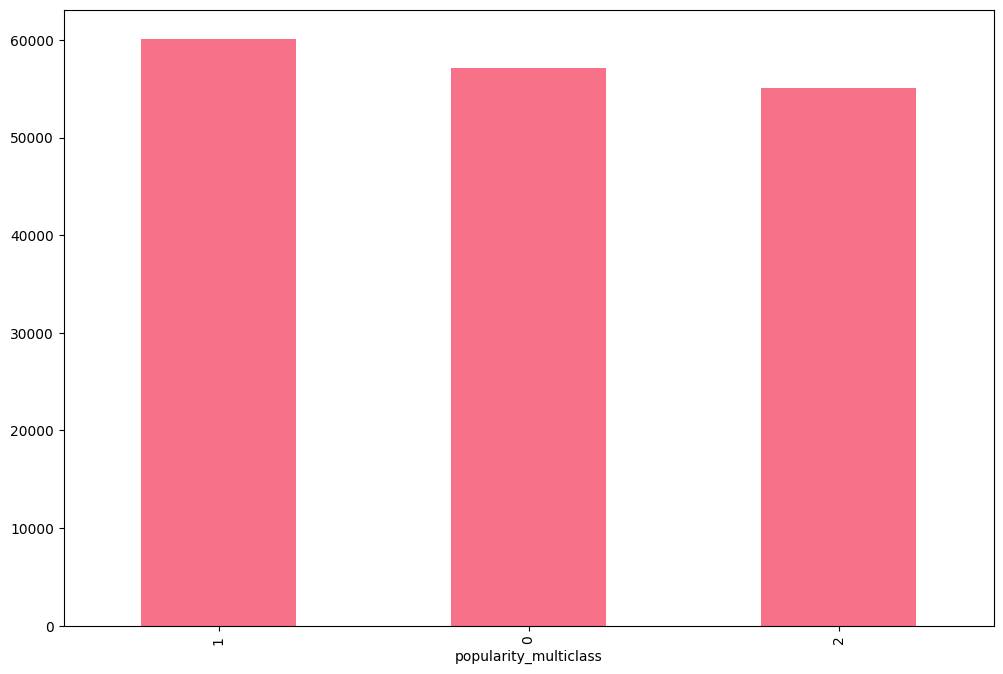

In [160]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

<Axes: xlabel='is_popular_binary'>

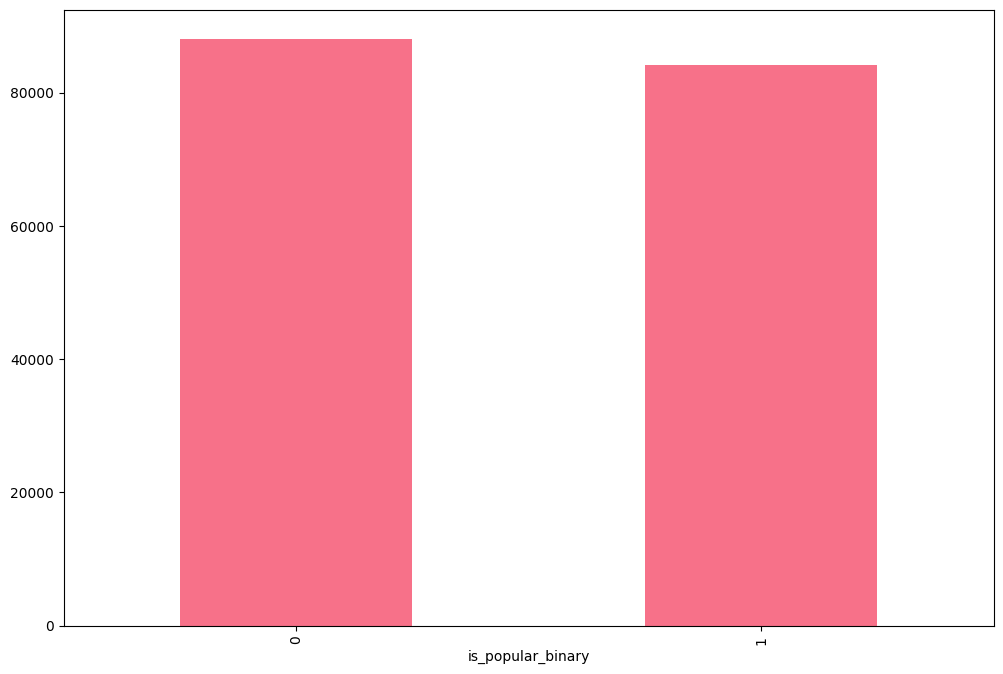

In [161]:
df_processed['is_popular_binary'].value_counts().plot(kind='bar')

In [162]:
scaler = RobustScaler()
scaler1 = RobustScaler()
scaler2 = RobustScaler()
_X = df_processed.copy()
X = _X.drop(columns=['popularity','popularity_multiclass','is_popular_binary','popularity_5levels'])
y_binary = df_processed['is_popular_binary']
y_multiclass_3 = df_processed['popularity_multiclass'] 
y_multiclass_5 = df_processed['popularity_5levels']


test_size = 0.2
random_state = 42

# División para clasificación binaria
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, 
    test_size=test_size, 
    stratify=y_binary,
    random_state=random_state
)
X_train_bin = scaler.fit_transform(X_train_bin)
# División para clasificación multiclase (3 niveles)
X_train_multi3, X_test_multi3, y_train_multi3, y_test_multi3 = train_test_split(
    X, y_multiclass_3, 
    test_size=test_size, 
    stratify=y_multiclass_3,
    random_state=random_state
)
X_train_multi3 = scaler1.fit_transform(X_train_multi3)
# División para clasificación multiclase (5 niveles)
X_train_multi5, X_test_multi5, y_train_multi5, y_test_multi5 = train_test_split(
    X, y_multiclass_5, 
    test_size=test_size, 
    stratify=y_multiclass_5,
    random_state=random_state
)
X_train_multi5= scaler2.fit_transform(X_train_multi5)


In [163]:
import time
base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10
    ),
    
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ),
    
    'Naive Bayes': GaussianNB(),
    
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        n_jobs=-1
    ),
}



Entrenando Logistic Regression...
   Completado - Accuracy: 0.8926, F1: 0.8927
Entrenando Random Forest...
   Completado - Accuracy: 0.9084, F1: 0.9071
Entrenando Gradient Boosting...
   Completado - Accuracy: 0.8988, F1: 0.8979
Entrenando Decision Tree...
   Completado - Accuracy: 0.9022, F1: 0.9017
Entrenando K-Nearest Neighbors...
   Completado - Accuracy: 0.8861, F1: 0.8851
Entrenando Naive Bayes...
   Completado - Accuracy: 0.8109, F1: 0.8254
Entrenando Extra Trees...
   Completado - Accuracy: 0.9023, F1: 0.9014
                Modelo  Accuracy  Precision  Recall  F1-Score  ROC AUC  \
0        Random Forest    0.9084     0.8996  0.9147    0.9071   0.9733   
1        Decision Tree    0.9022     0.8860  0.9179    0.9017   0.9659   
2          Extra Trees    0.9023     0.8895  0.9136    0.9014   0.9661   
3    Gradient Boosting    0.8988     0.8859  0.9102    0.8979   0.9689   
4  Logistic Regression    0.8926     0.8723  0.9141    0.8927   0.9656   
5  K-Nearest Neighbors    0.8861 

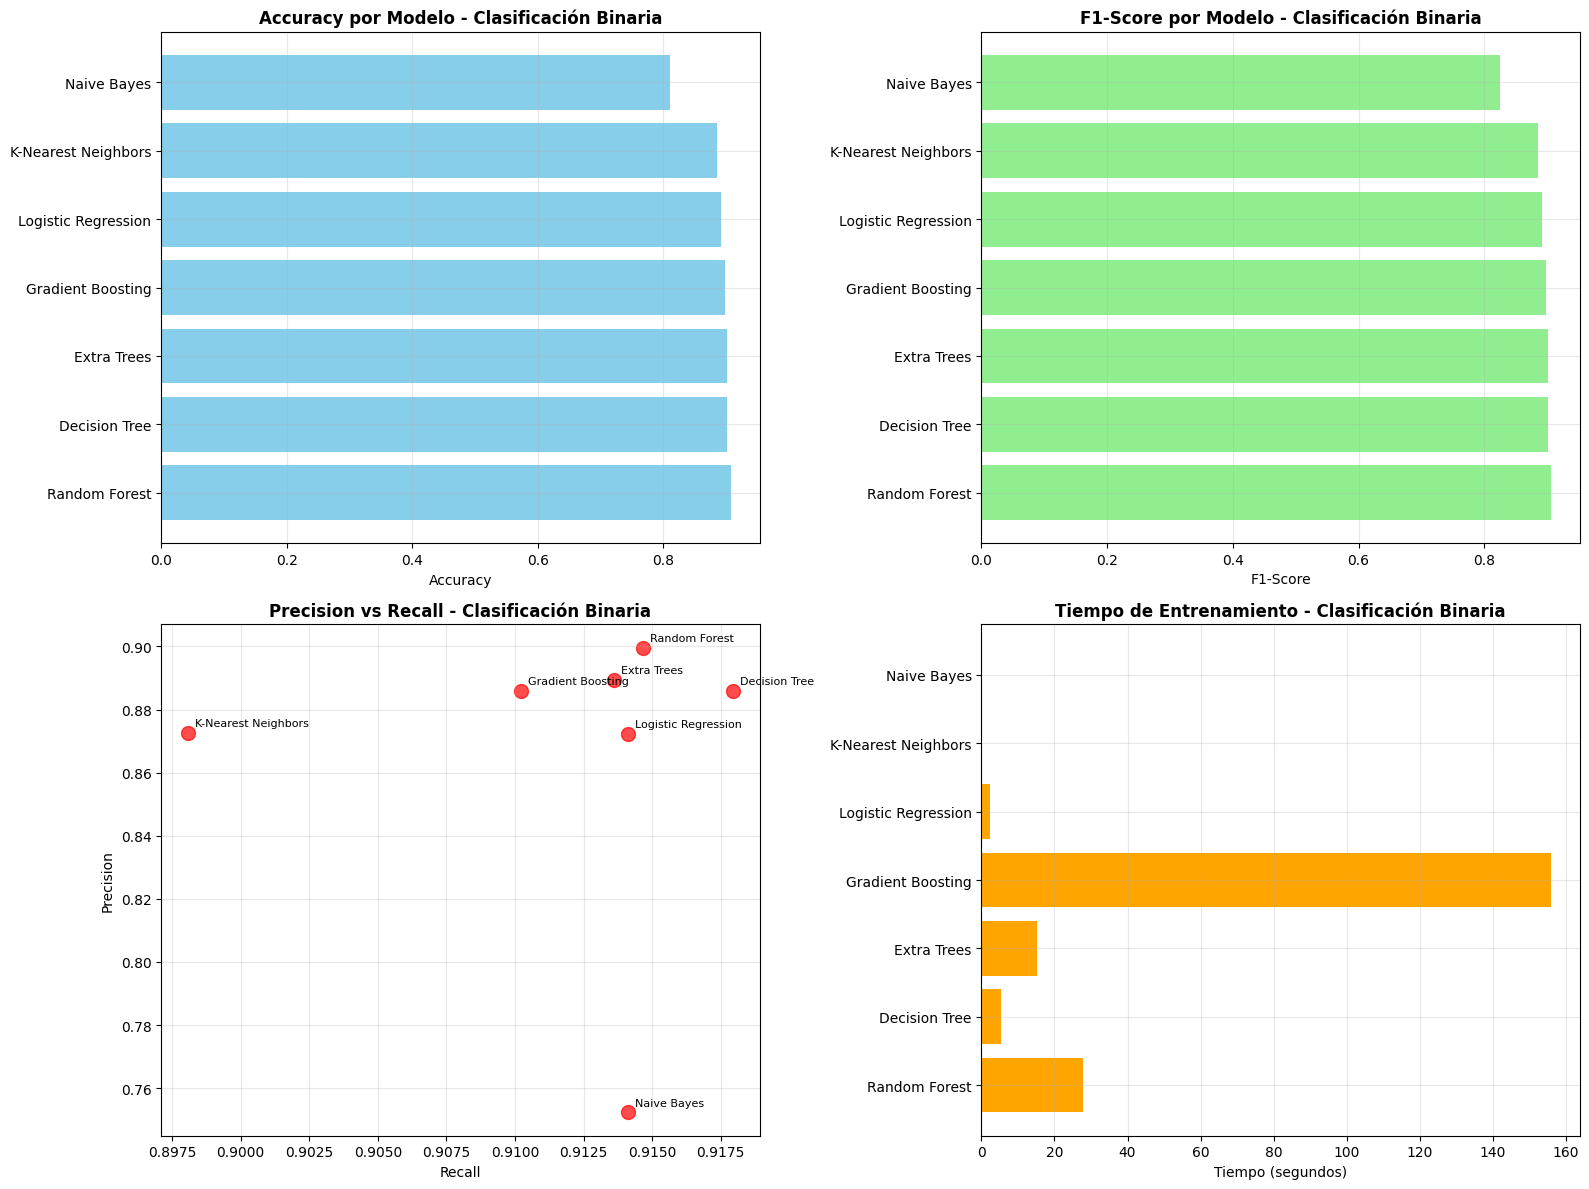

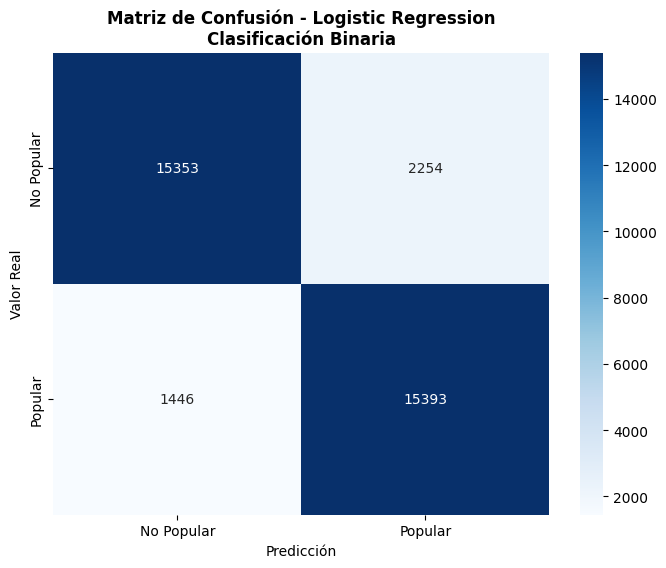

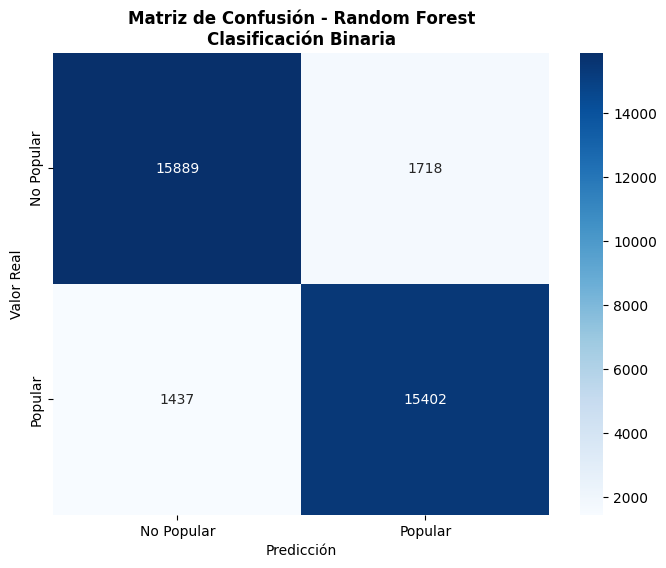

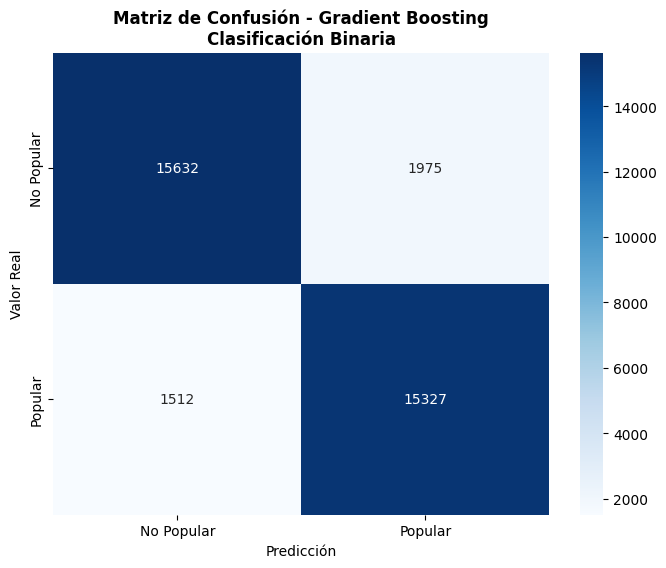

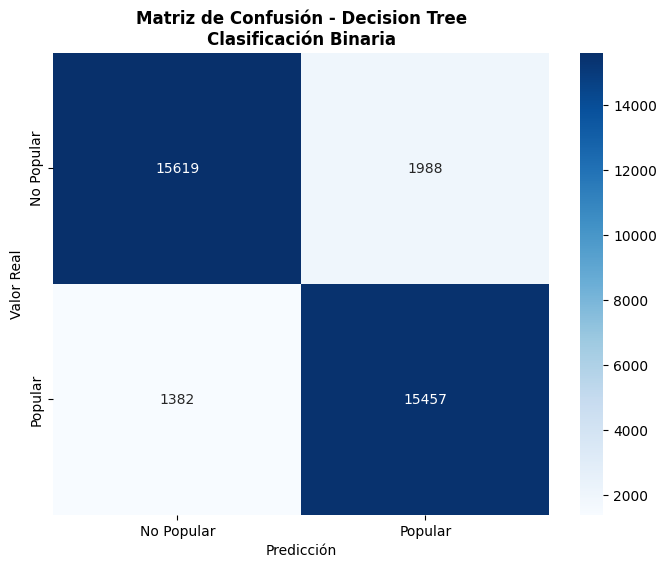

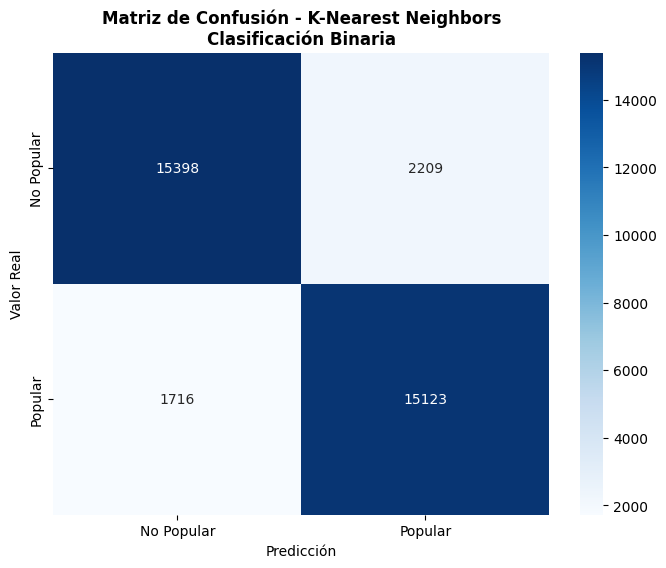

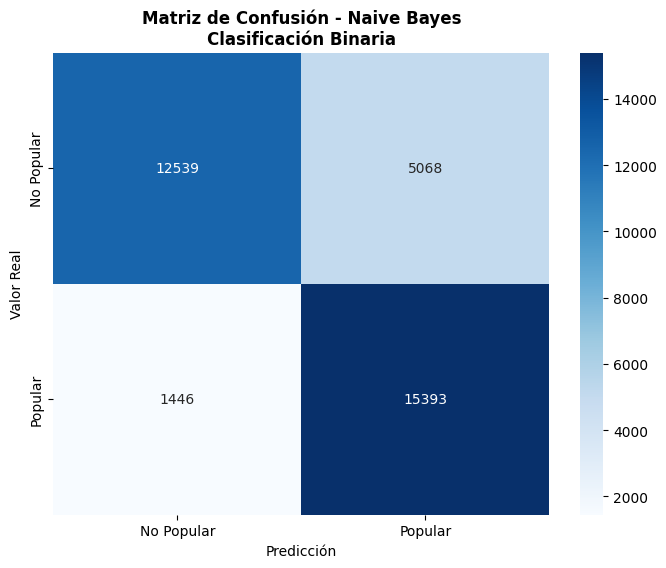

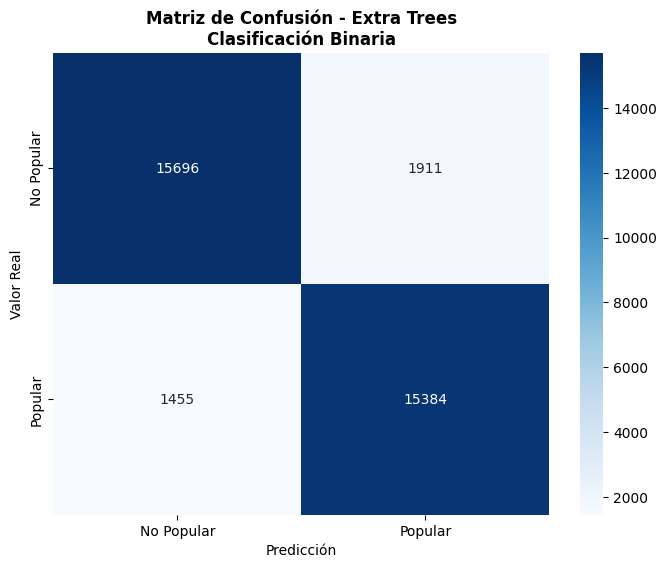


Clasificación binaria completada con 7 modelos


In [164]:
# CLASIFICACIÓN BINARIA 

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, task_type,_scaler):
    """
    Evalúa un modelo y retorna métricas de rendimiento
    """
    print(f"Entrenando {model_name}...",flush=True)

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
   
    start_time = time.time()
    X_test = _scaler.transform(X_test)
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_time
    
 
    accuracy = accuracy_score(y_test, y_pred)
    
    if task_type == 'binary':
        precision = precision_score(y_test, y_pred, pos_label=1)
        recall = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)
        
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        else:
            roc_auc = None
    else:
     
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        roc_auc = None  
        
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}",flush=True)

    results = {
        'model_name': model_name,
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    return results




binary_results = [] 
for model_name, model in base_models.items():
    try:
        result = evaluate_model(
            model=model,
            X_train=X_train_bin,
            X_test=X_test_bin,
            y_train=y_train_bin,
            y_test=y_test_bin,
            model_name=model_name,
            task_type='binary',
            _scaler=scaler
        )
        binary_results.append(result)
    except Exception as e:
        print(f"   ❌ Error con {model_name}: {str(e)}")


binary_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'ROC AUC': r['roc_auc'] if r['roc_auc'] else 'N/A',
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in binary_results])

binary_df = binary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)


print(binary_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].barh(binary_df['Modelo'], binary_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Clasificación Binaria', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].barh(binary_df['Modelo'], binary_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Clasificación Binaria', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(binary_df['Recall'], binary_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(binary_df['Modelo']):
    axes[1,0].annotate(txt, (binary_df['Recall'].iloc[i], binary_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Clasificación Binaria', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(binary_df['Modelo'], binary_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Clasificación Binaria', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


best_binary_model = binary_results[0]['model_object']
best_binary_name = binary_results[0]['model_name']

for i,_ in enumerate(binary_results):
    plt.figure(figsize=(8, 6))
    cm = binary_results[i]['confusion_matrix']
    name = binary_results[i]['model_name']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'Popular'],
                yticklabels=['No Popular', 'Popular'])
    plt.title(f'Matriz de Confusión - {name}\nClasificación Binaria', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

print(f"\nClasificación binaria completada con {len(binary_results)} modelos")

Entrenando Random Forest...
   Completado - Accuracy: 0.8490, F1: 0.8489
Entrenando Gradient Boosting...
   Completado - Accuracy: 0.8345, F1: 0.8348
Entrenando Decision Tree...
   Completado - Accuracy: 0.8356, F1: 0.8362
Entrenando K-Nearest Neighbors...
   Completado - Accuracy: 0.7998, F1: 0.7997
Entrenando Extra Trees...
   Completado - Accuracy: 0.8358, F1: 0.8356
                Modelo  Accuracy  Precision  Recall  F1-Score  \
0        Random Forest    0.8490     0.8506  0.8490    0.8489   
1        Decision Tree    0.8356     0.8409  0.8356    0.8362   
2          Extra Trees    0.8358     0.8365  0.8358    0.8356   
3    Gradient Boosting    0.8345     0.8372  0.8345    0.8348   
4  K-Nearest Neighbors    0.7998     0.7997  0.7998    0.7997   

   Tiempo Entrenamiento (s)  Tiempo Predicción (s)  
0                   22.8141                 0.4568  
1                    4.4762                 0.0388  
2                   14.3019                 0.6049  
3                  447.5

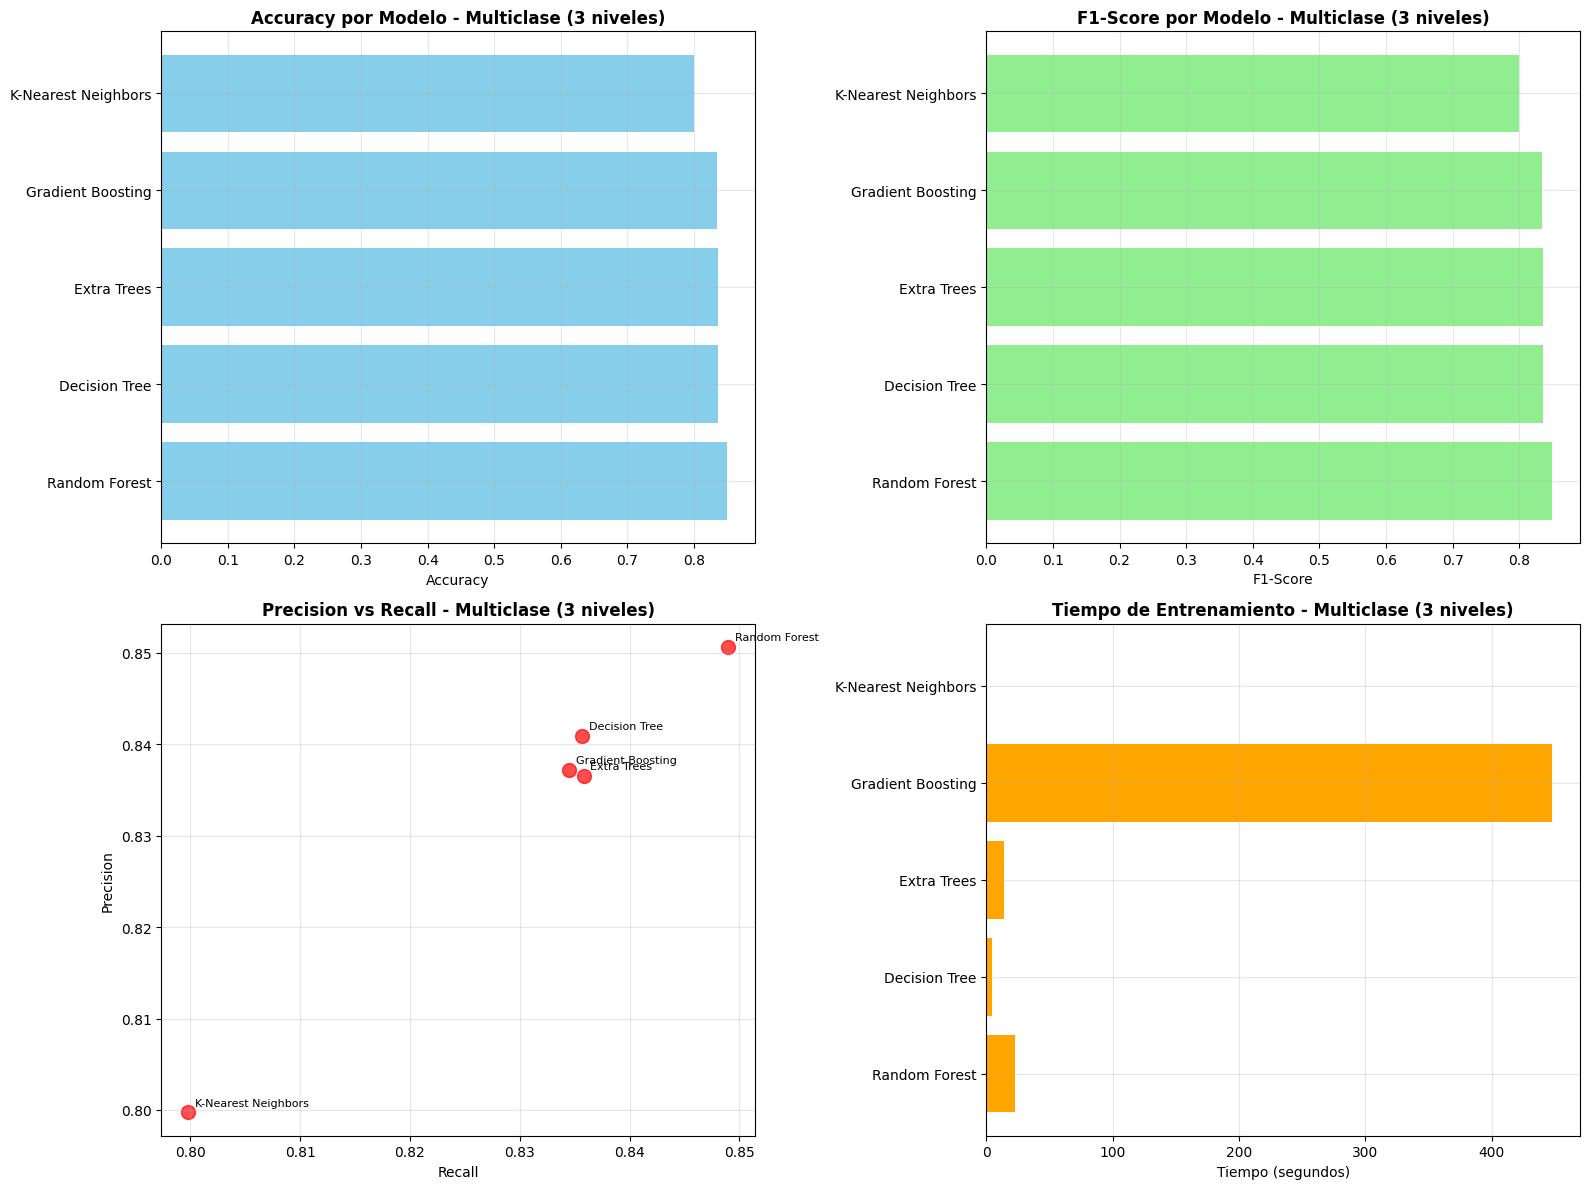

              precision    recall  f1-score   support

        Baja     0.9426    0.9524    0.9475     11416
       Media     0.7666    0.8219    0.7933     12018
        Alta     0.8470    0.7712    0.8073     11012

    accuracy                         0.8490     34446
   macro avg     0.8521    0.8485    0.8494     34446
weighted avg     0.8506    0.8490    0.8489     34446



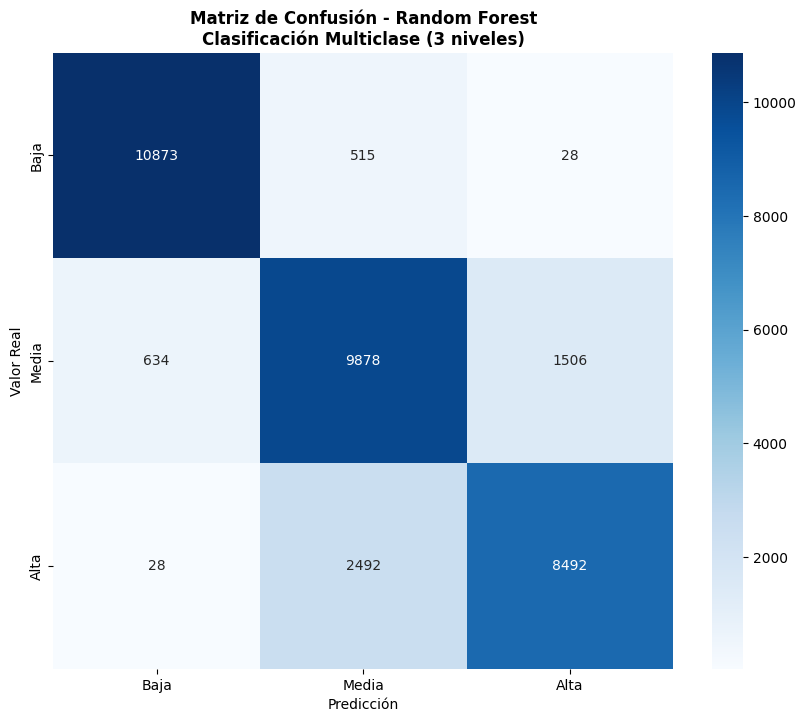

              precision    recall  f1-score   support

        Baja     0.9347    0.9332    0.9339     11416
       Media     0.7455    0.8089    0.7759     12018
        Alta     0.8363    0.7602    0.7964     11012

    accuracy                         0.8345     34446
   macro avg     0.8388    0.8341    0.8354     34446
weighted avg     0.8372    0.8345    0.8348     34446



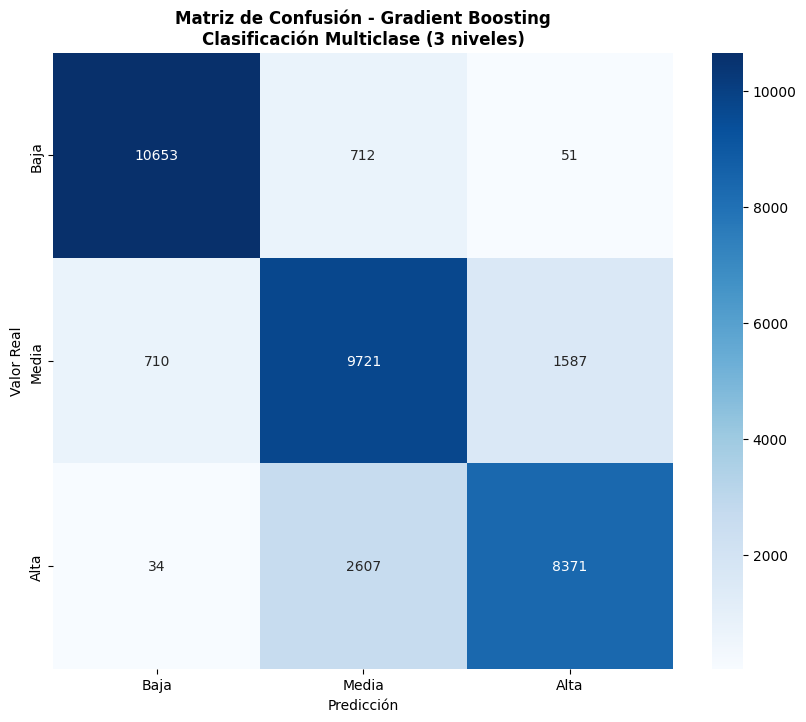

              precision    recall  f1-score   support

        Baja     0.9435    0.9300    0.9367     11416
       Media     0.7378    0.8307    0.7815     12018
        Alta     0.8470    0.7432    0.7917     11012

    accuracy                         0.8356     34446
   macro avg     0.8428    0.8346    0.8366     34446
weighted avg     0.8409    0.8356    0.8362     34446



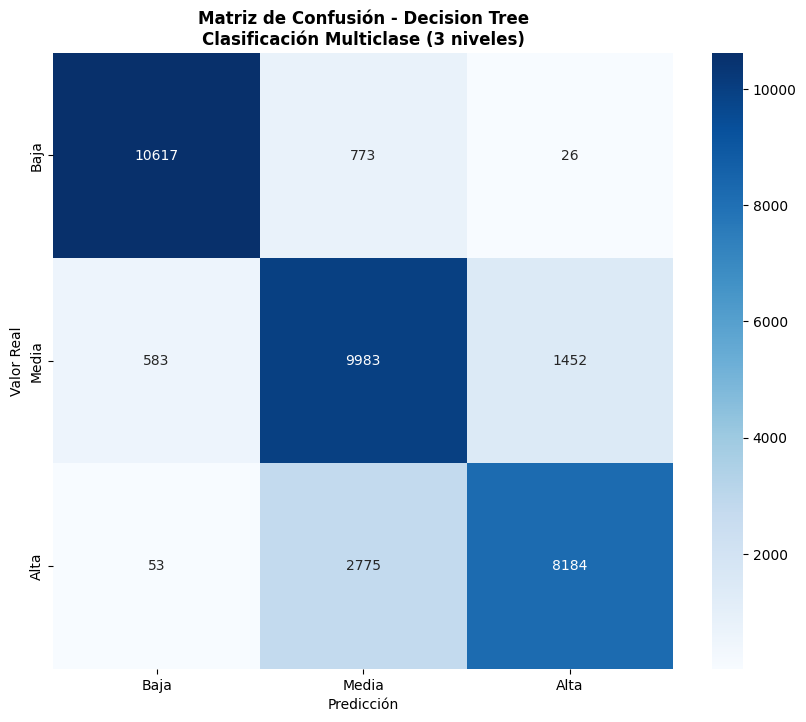

              precision    recall  f1-score   support

        Baja     0.9240    0.9291    0.9266     11416
       Media     0.7178    0.7286    0.7232     12018
        Alta     0.7602    0.7435    0.7518     11012

    accuracy                         0.7998     34446
   macro avg     0.8007    0.8004    0.8005     34446
weighted avg     0.7997    0.7998    0.7997     34446



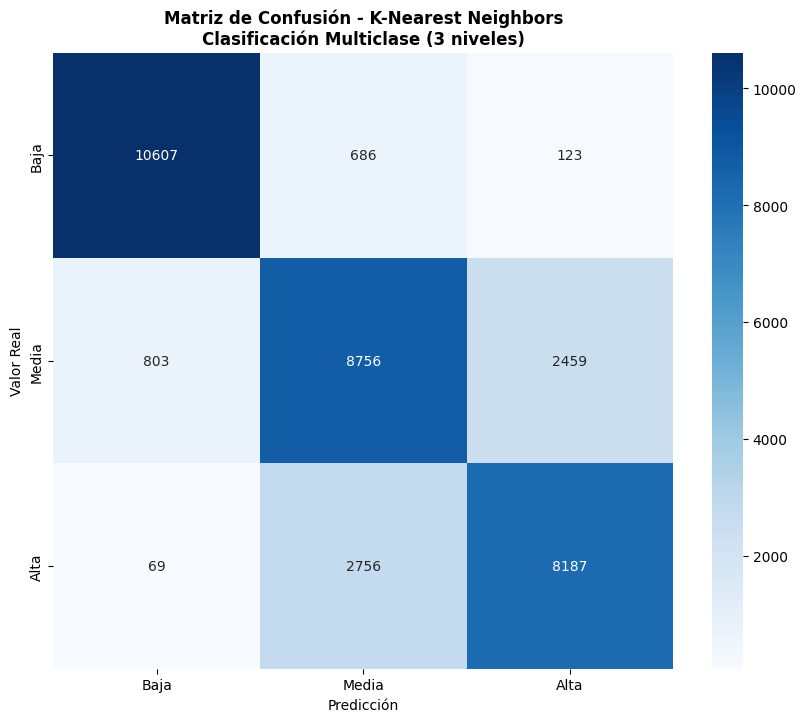

              precision    recall  f1-score   support

        Baja     0.9377    0.9502    0.9439     11416
       Media     0.7538    0.7935    0.7731     12018
        Alta     0.8220    0.7633    0.7916     11012

    accuracy                         0.8358     34446
   macro avg     0.8378    0.8357    0.8362     34446
weighted avg     0.8365    0.8358    0.8356     34446



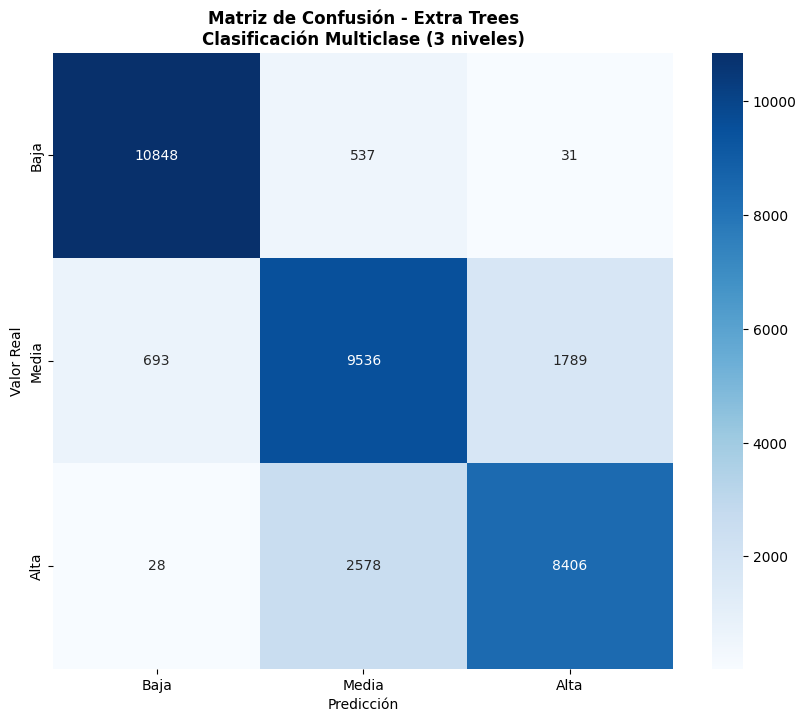


Clasificación multiclase (3 niveles) completada con 5 modelos


In [165]:
# CLASIFICACIÓN MULTICLASE (3 NIVELES) 


multiclass3_results = []

for model_name, model in base_models.items():
    if model_name == 'Logistic Regression' or model_name=='Naive Bayes':
        continue
    try:
        result = evaluate_model(
            model=model,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass',
            _scaler=scaler1
        )
        multiclass3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con {model_name}: {str(e)}")

multiclass3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in multiclass3_results])

multiclass3_df = multiclass3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)


print(multiclass3_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].barh(multiclass3_df['Modelo'], multiclass3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (3 niveles)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].barh(multiclass3_df['Modelo'], multiclass3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (3 niveles)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(multiclass3_df['Recall'], multiclass3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(multiclass3_df['Modelo']):
    axes[1,0].annotate(txt, (multiclass3_df['Recall'].iloc[i], multiclass3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (3 niveles)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(multiclass3_df['Modelo'], multiclass3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (3 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


best_multi3_model = multiclass3_results[0]['model_object']
best_multi3_name = multiclass3_results[0]['model_name']


for i,_ in enumerate(multiclass3_results):
    plt.figure(figsize=(10, 8))
    cm = multiclass3_results[i]['confusion_matrix']
    _name = multiclass3_results[i]['model_name']
    class_names = ['Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {_name}\nClasificación Multiclase (3 niveles)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, multiclass3_results[i]['predictions'], 
                             target_names=class_names, digits=4)
    print(report)
    plt.show()



print(f"\nClasificación multiclase (3 niveles) completada con {len(multiclass3_results)} modelos")

Entrenando Random Forest...
   Completado - Accuracy: 0.7498, F1: 0.7495
Entrenando Gradient Boosting...
   Completado - Accuracy: 0.7291, F1: 0.7301
Entrenando Decision Tree...
   Completado - Accuracy: 0.7266, F1: 0.7275
Entrenando K-Nearest Neighbors...
   Completado - Accuracy: 0.6633, F1: 0.6626
Entrenando Extra Trees...
   Completado - Accuracy: 0.7310, F1: 0.7306
                Modelo  Accuracy  Precision  Recall  F1-Score  \
0        Random Forest    0.7498     0.7522  0.7498    0.7495   
1          Extra Trees    0.7310     0.7322  0.7310    0.7306   
2    Gradient Boosting    0.7291     0.7366  0.7291    0.7301   
3        Decision Tree    0.7266     0.7350  0.7266    0.7275   
4  K-Nearest Neighbors    0.6633     0.6624  0.6633    0.6626   

   Tiempo Entrenamiento (s)  Tiempo Predicción (s)  
0                   17.7594                 0.5295  
1                   22.1765                 0.5874  
2                  786.1918                 1.4157  
3                    5.3

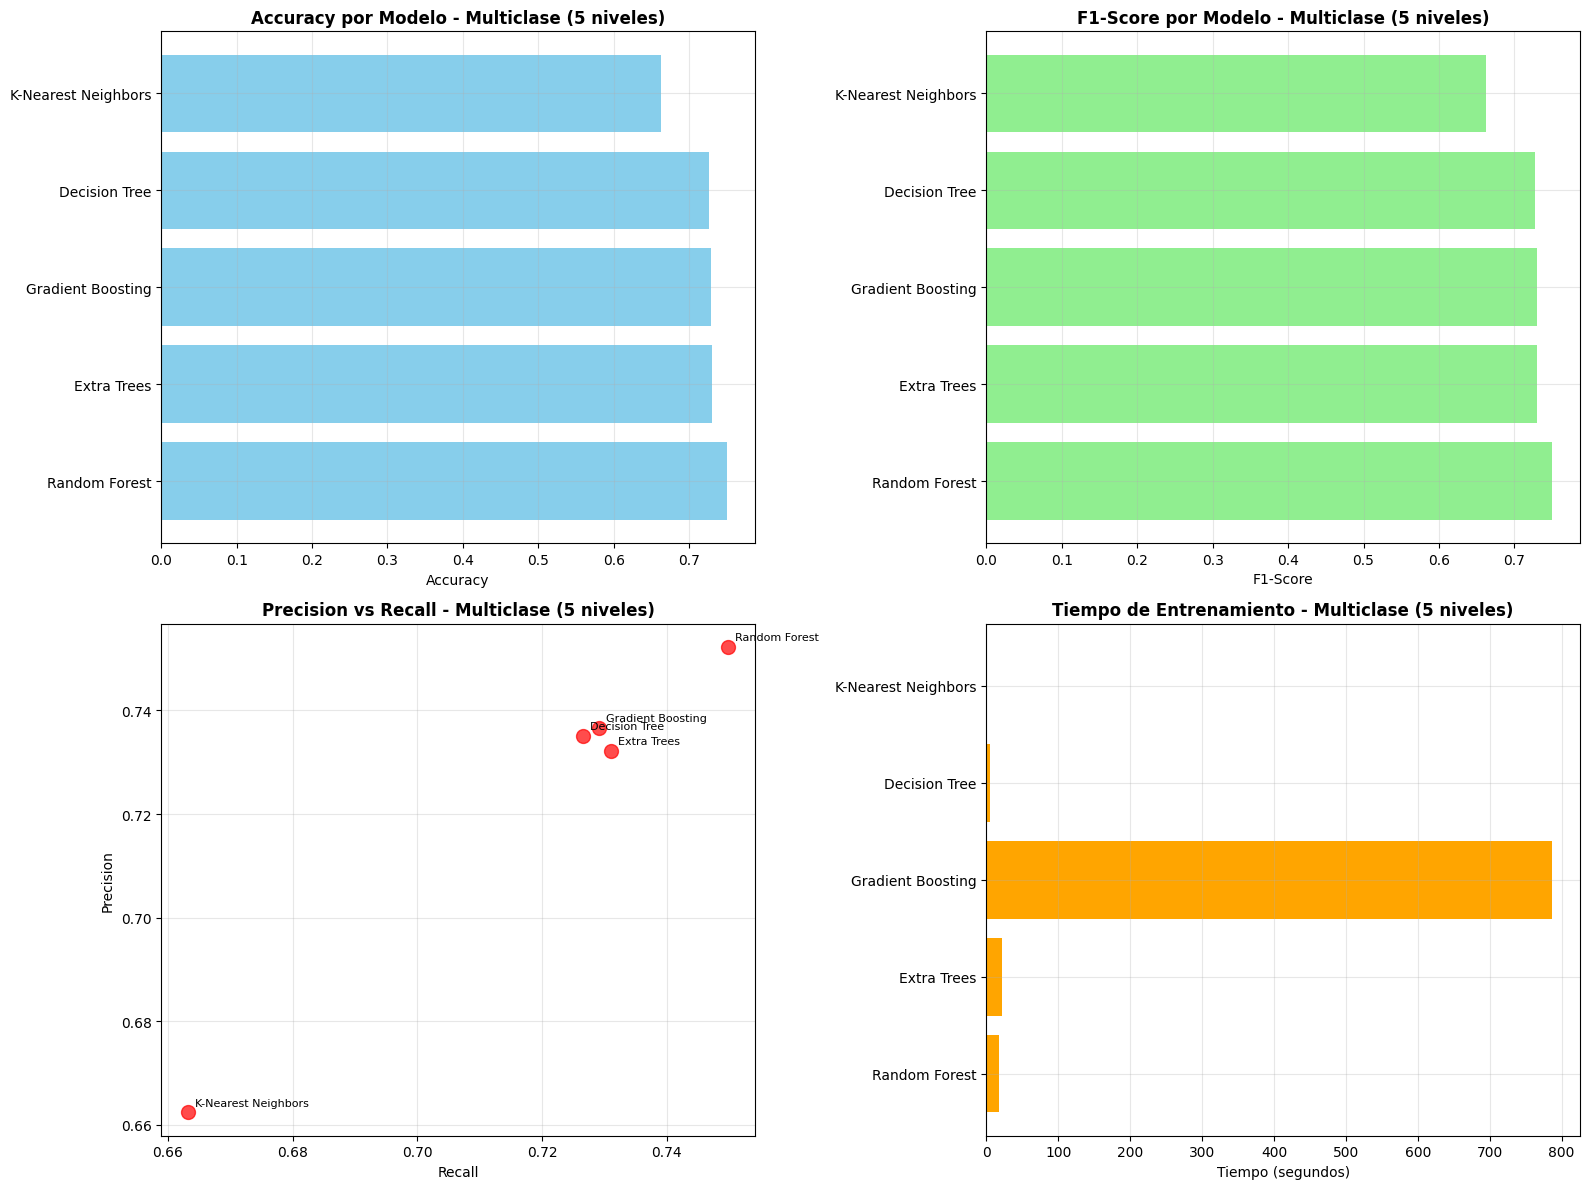

              precision    recall  f1-score   support

    Muy Baja     0.9326    0.9547    0.9435      7946
        Baja     0.7663    0.8134    0.7891      5836
       Media     0.6177    0.6853    0.6498      6918
        Alta     0.6009    0.5743    0.5873      6861
    Muy Alta     0.8180    0.6992    0.7540      6885

    accuracy                         0.7498     34446
   macro avg     0.7471    0.7454    0.7447     34446
weighted avg     0.7522    0.7498    0.7495     34446



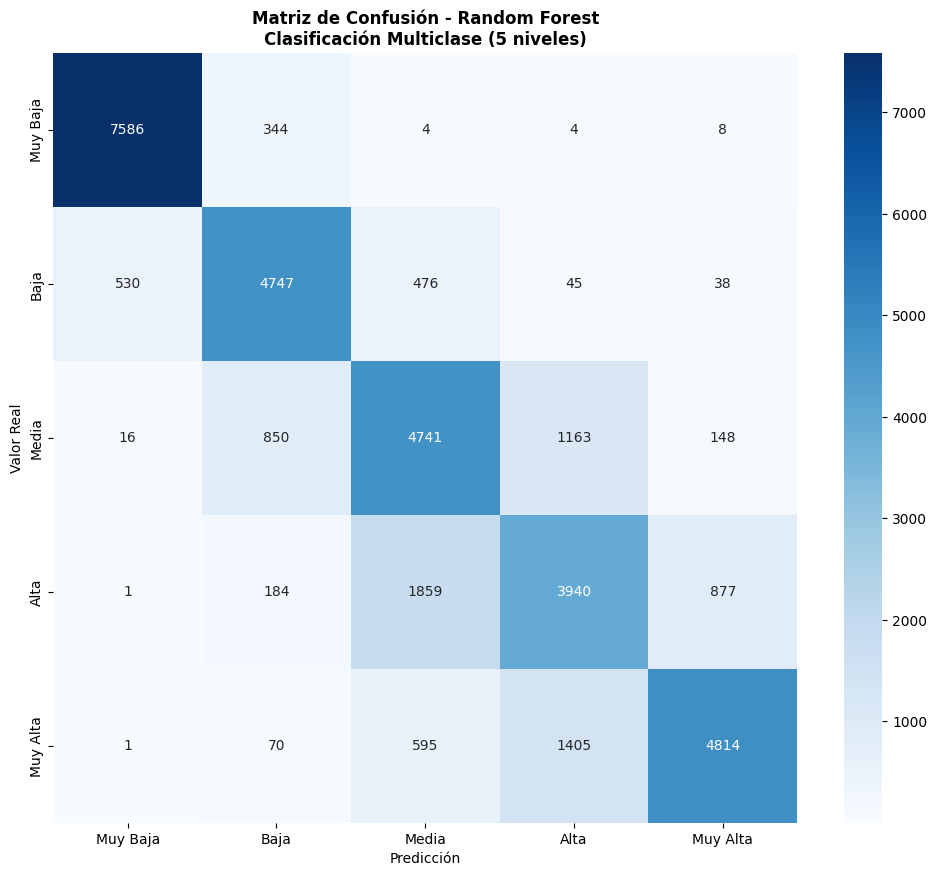

              precision    recall  f1-score   support

    Muy Baja     0.9216    0.9280    0.9248      7946
        Baja     0.7037    0.7832    0.7413      5836
       Media     0.5855    0.6645    0.6225      6918
        Alta     0.5959    0.5716    0.5835      6861
    Muy Alta     0.8432    0.6755    0.7501      6885

    accuracy                         0.7291     34446
   macro avg     0.7300    0.7246    0.7245     34446
weighted avg     0.7366    0.7291    0.7301     34446



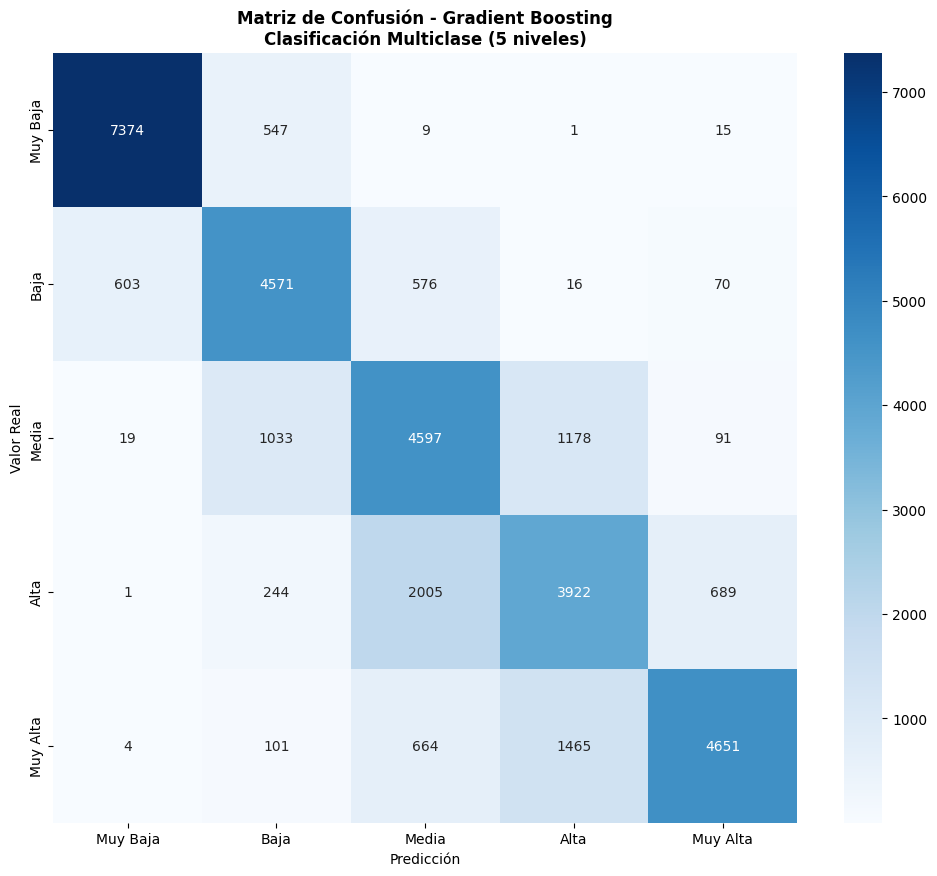

              precision    recall  f1-score   support

    Muy Baja     0.9196    0.9283    0.9239      7946
        Baja     0.6859    0.8035    0.7401      5836
       Media     0.6010    0.6080    0.6045      6918
        Alta     0.5767    0.6085    0.5922      6861
    Muy Alta     0.8561    0.6654    0.7488      6885

    accuracy                         0.7266     34446
   macro avg     0.7279    0.7227    0.7219     34446
weighted avg     0.7350    0.7266    0.7275     34446



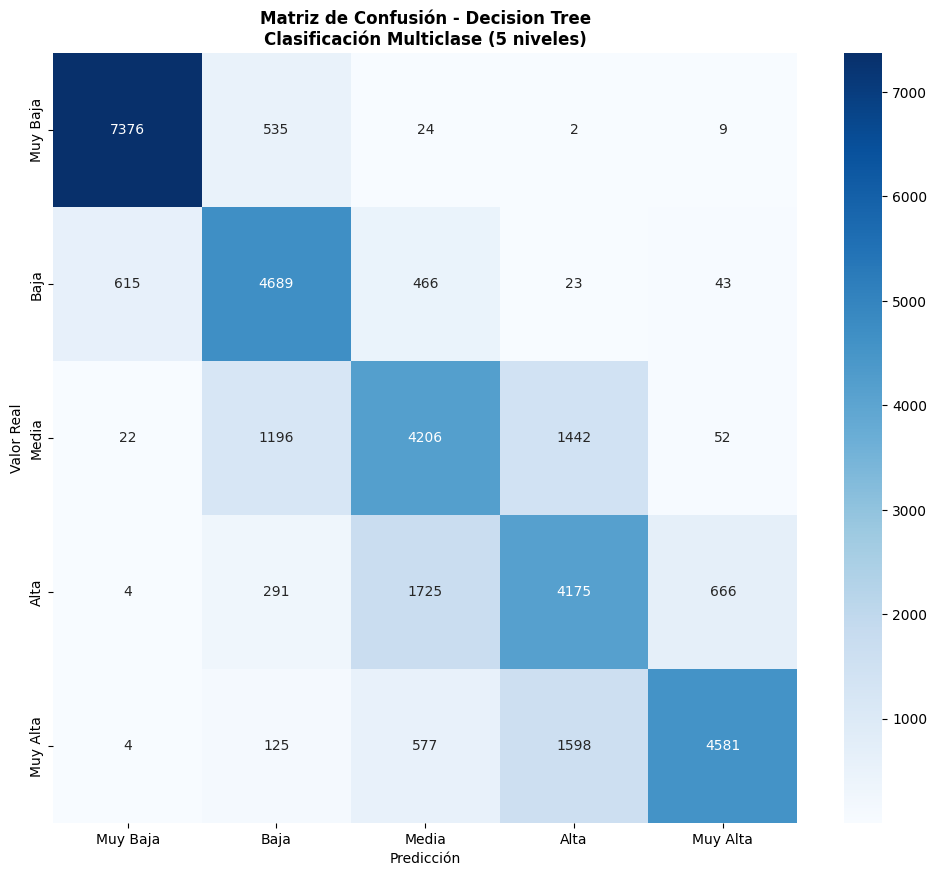

              precision    recall  f1-score   support

    Muy Baja     0.8799    0.9076    0.8936      7946
        Baja     0.6910    0.6859    0.6885      5836
       Media     0.5316    0.5580    0.5445      6918
        Alta     0.4934    0.4804    0.4868      6861
    Muy Alta     0.6869    0.6501    0.6680      6885

    accuracy                         0.6633     34446
   macro avg     0.6566    0.6564    0.6563     34446
weighted avg     0.6624    0.6633    0.6626     34446



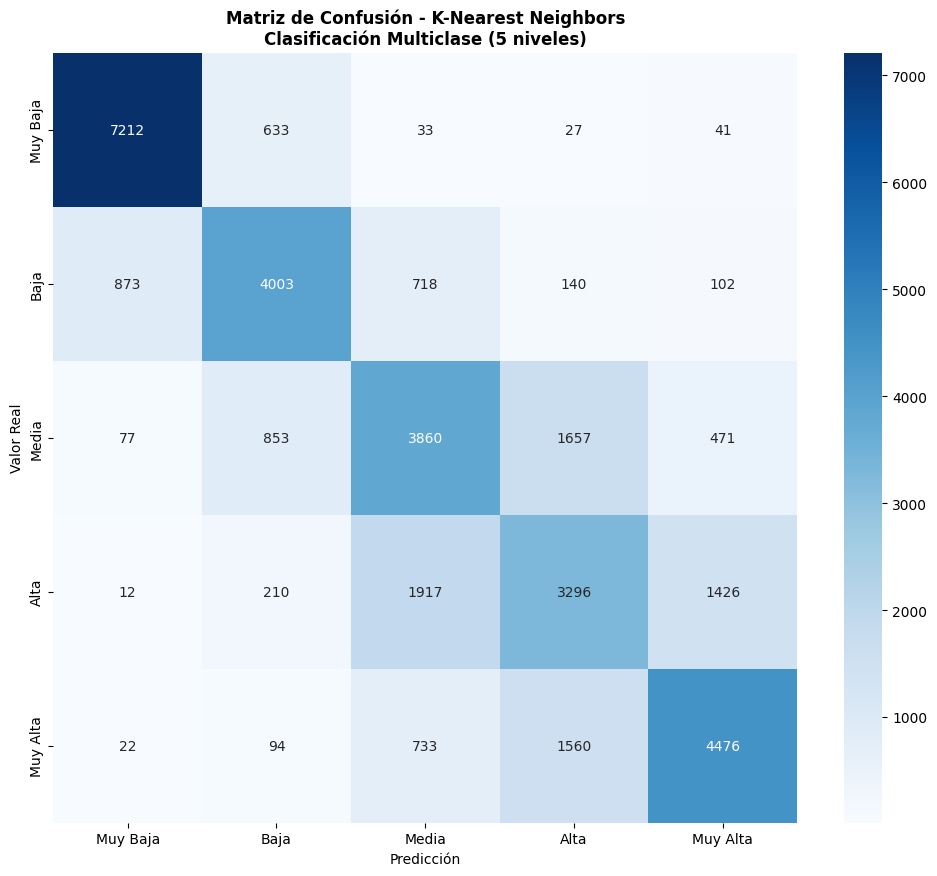

              precision    recall  f1-score   support

    Muy Baja     0.9148    0.9554    0.9347      7946
        Baja     0.7620    0.7730    0.7674      5836
       Media     0.5984    0.6522    0.6242      6918
        Alta     0.5716    0.5574    0.5644      6861
    Muy Alta     0.7907    0.6887    0.7362      6885

    accuracy                         0.7310     34446
   macro avg     0.7275    0.7253    0.7254     34446
weighted avg     0.7322    0.7310    0.7306     34446



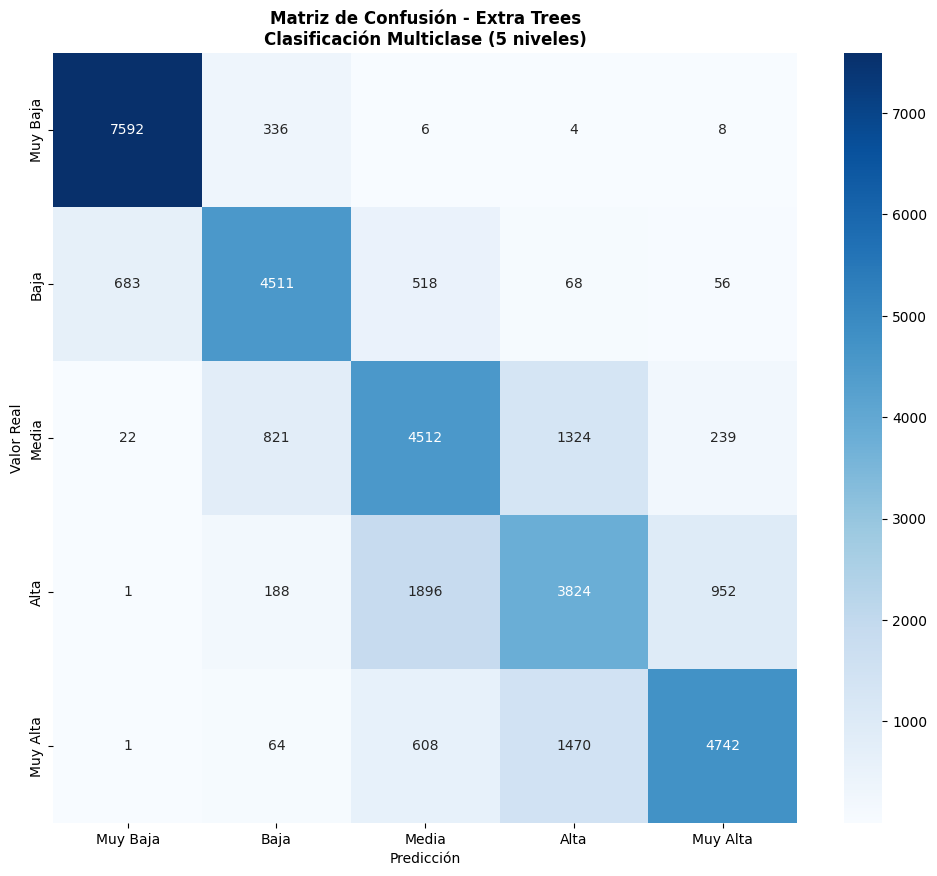


Clasificación multiclase (5 niveles) completada con 5 modelos


In [166]:

multiclass5_results = []

for model_name, model in base_models.items():
    try:
        if model_name == 'Logistic Regression' or model_name=='Naive Bayes':
            continue
        result = evaluate_model(
            model=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass',
            _scaler = scaler2
        )
        multiclass5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con {model_name}: {str(e)}")

multiclass5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in multiclass5_results])

multiclass5_df = multiclass5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(multiclass5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(multiclass5_df['Modelo'], multiclass5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (5 niveles)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(multiclass5_df['Modelo'], multiclass5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (5 niveles)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(multiclass5_df['Recall'], multiclass5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(multiclass5_df['Modelo']):
    axes[1,0].annotate(txt, (multiclass5_df['Recall'].iloc[i], multiclass5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (5 niveles)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(multiclass5_df['Modelo'], multiclass5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (5 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_multi5_model = multiclass5_results[0]['model_object']
best_multi5_name = multiclass5_results[0]['model_name']

for i,_ in enumerate(multiclass5_results):
    plt.figure(figsize=(12, 10))
    cm = multiclass5_results[i]['confusion_matrix']
    name_ = multiclass5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (5 niveles)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, multiclass5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()




print(f"\nClasificación multiclase (5 niveles) completada con {len(multiclass5_results)} modelos")

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.8123, F1: 0.8109, Clasificadores: 3
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.8386, F1: 0.8388, Clasificadores: 3
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.8490, F1: 0.8491, Clasificadores: 3
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.8303, F1: 0.8303, Clasificadores: 3
Entrenando OvR xgboost...
   Completado - Accuracy: 0.8477, F1: 0.8481, Clasificadores: 3
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.6876, F1: 0.6859, Clasificadores: 3

RESULTADOS OvR - MULTICLASE (3 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.8490     0.8506  0.8490    0.8491   
1              OvR xgboost    0.8477     0.8510  0.8477    0.8481   
2        OvR Decision Tree    0.8386     0.8439  0.8386    0.8388   
3    OvR Gradient Boosting    0.8303     0.8326  0.8303    0.8303   
4  OvR Logistic Regression    0.812

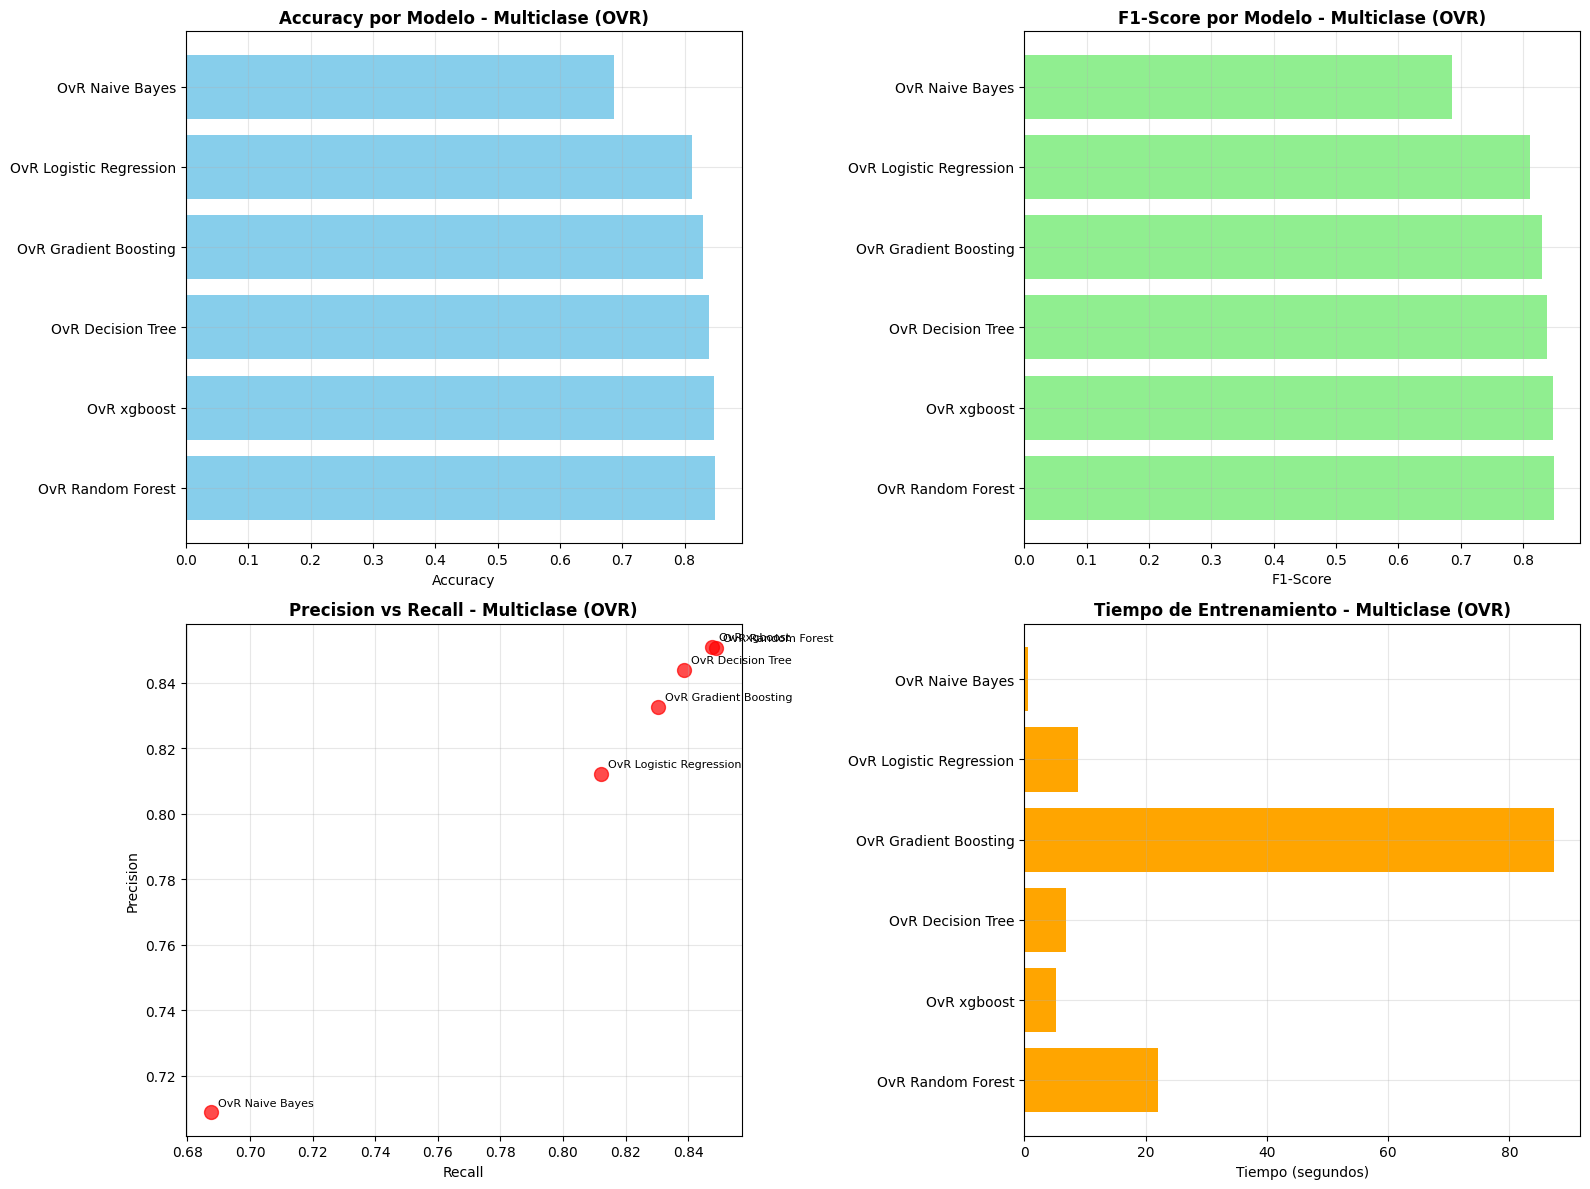

              precision    recall  f1-score   support

        Baja     0.8837    0.9455    0.9135     11416
       Media     0.7302    0.7592    0.7444     12018
        Alta     0.8280    0.7320    0.7771     11012

    accuracy                         0.8123     34446
   macro avg     0.8140    0.8122    0.8117     34446
weighted avg     0.8123    0.8123    0.8109     34446



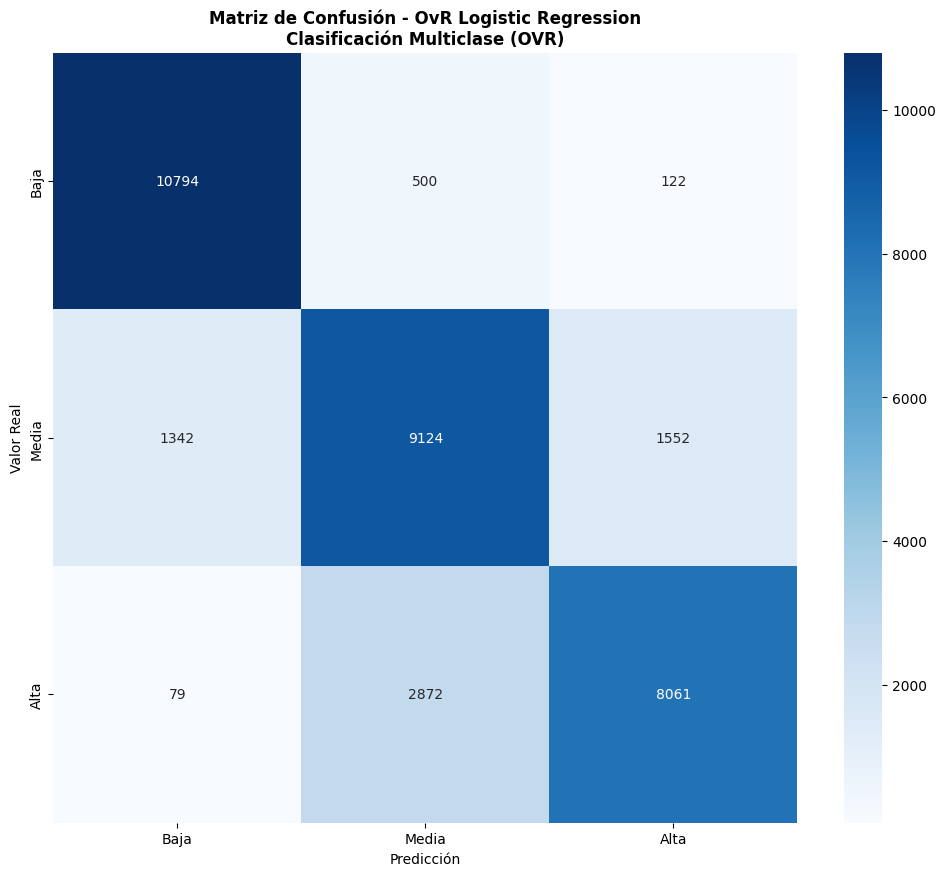

              precision    recall  f1-score   support

        Baja     0.9387    0.9382    0.9384     11416
       Media     0.7407    0.8369    0.7859     12018
        Alta     0.8583    0.7372    0.7932     11012

    accuracy                         0.8386     34446
   macro avg     0.8459    0.8374    0.8392     34446
weighted avg     0.8439    0.8386    0.8388     34446



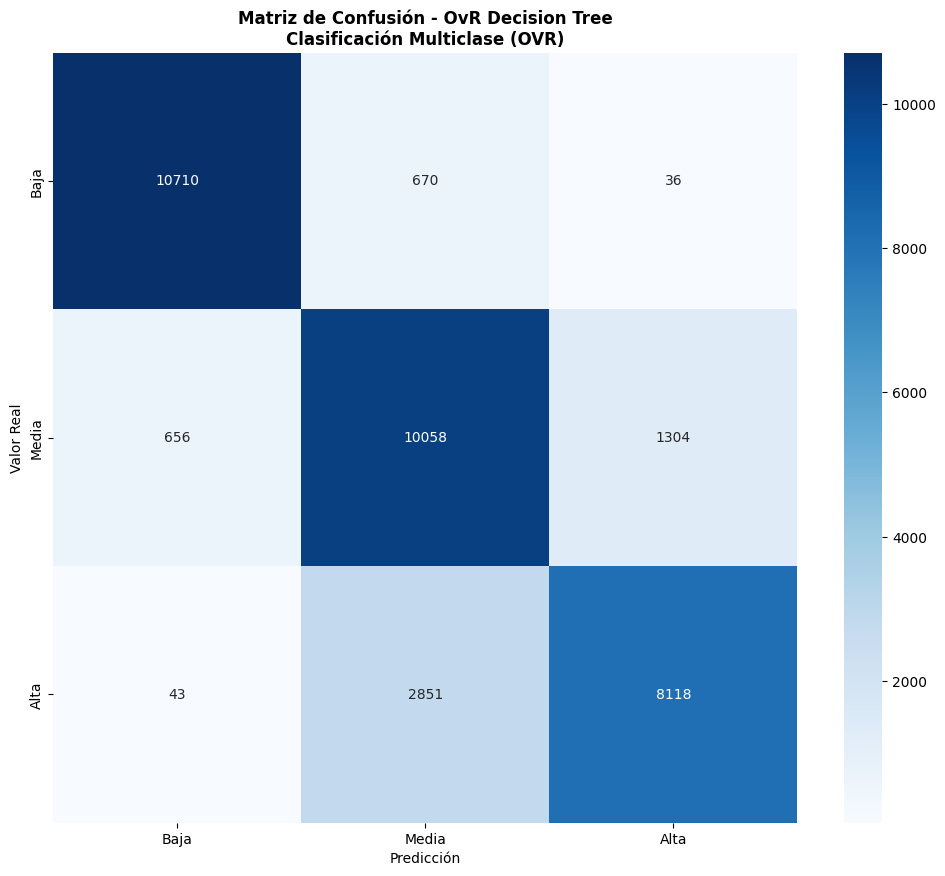

              precision    recall  f1-score   support

        Baja     0.9452    0.9502    0.9477     11416
       Media     0.7677    0.8204    0.7932     12018
        Alta     0.8431    0.7753    0.8078     11012

    accuracy                         0.8490     34446
   macro avg     0.8520    0.8486    0.8496     34446
weighted avg     0.8506    0.8490    0.8491     34446



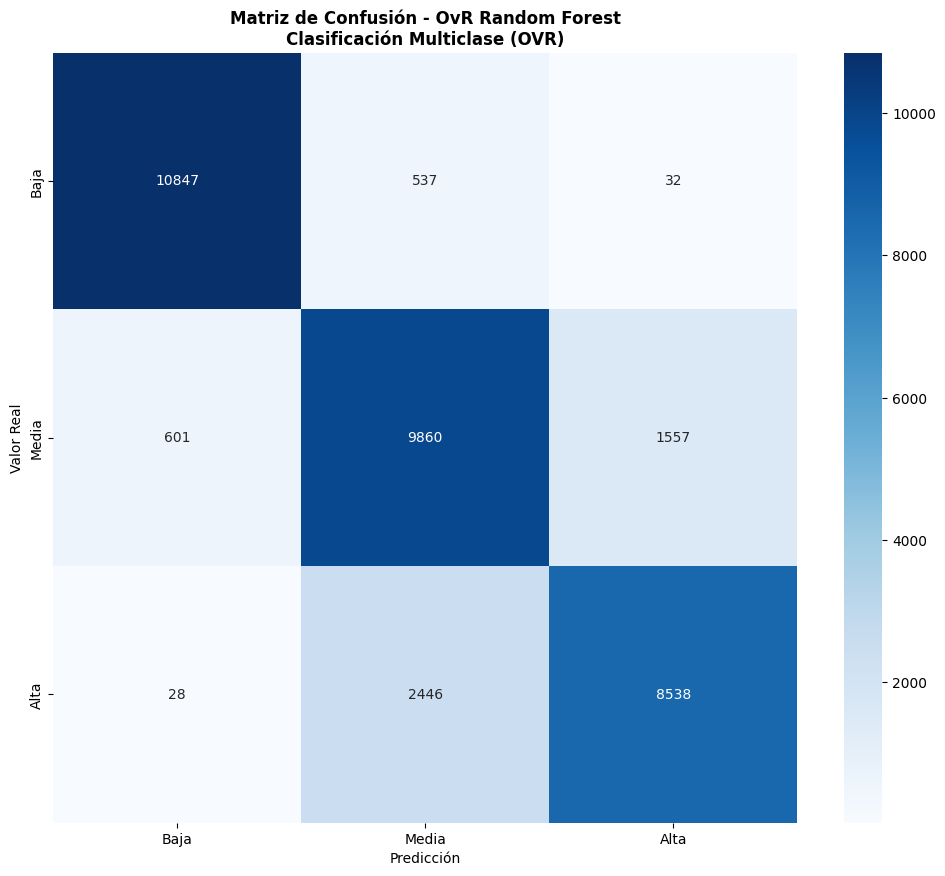

              precision    recall  f1-score   support

        Baja     0.9234    0.9347    0.9290     11416
       Media     0.7420    0.8013    0.7705     12018
        Alta     0.8373    0.7535    0.7932     11012

    accuracy                         0.8303     34446
   macro avg     0.8342    0.8299    0.8309     34446
weighted avg     0.8326    0.8303    0.8303     34446



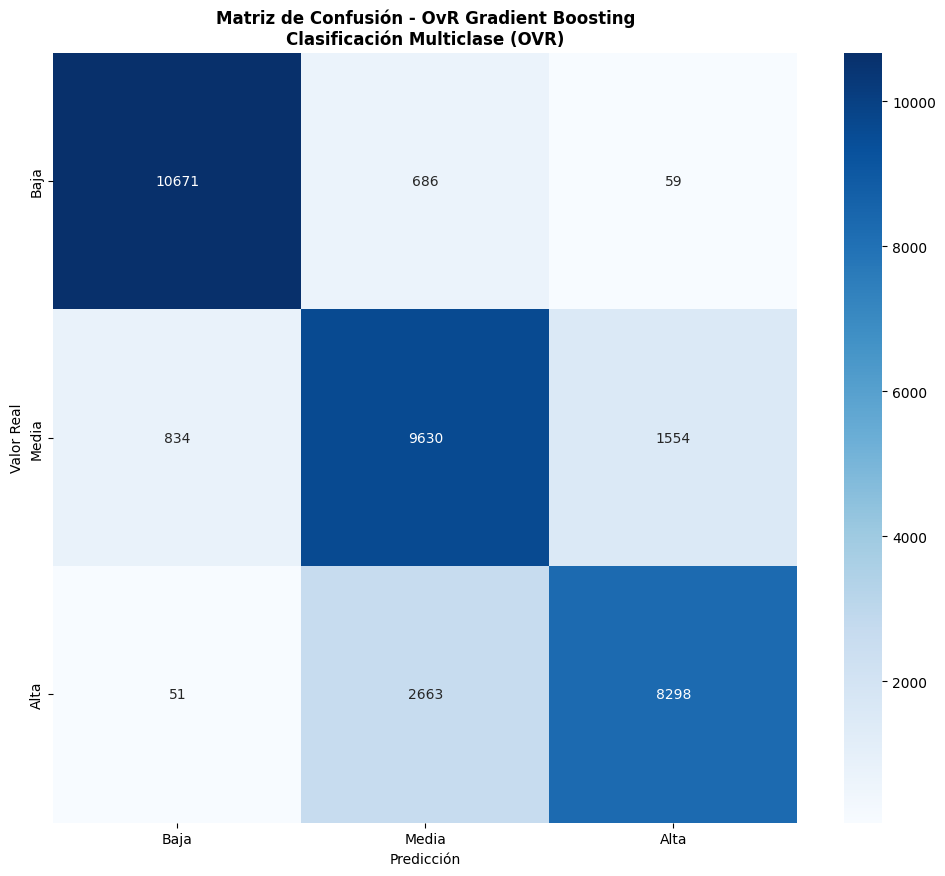

              precision    recall  f1-score   support

        Baja     0.9492    0.9416    0.9454     11416
       Media     0.7592    0.8322    0.7940     12018
        Alta     0.8492    0.7673    0.8062     11012

    accuracy                         0.8477     34446
   macro avg     0.8526    0.8470    0.8485     34446
weighted avg     0.8510    0.8477    0.8481     34446



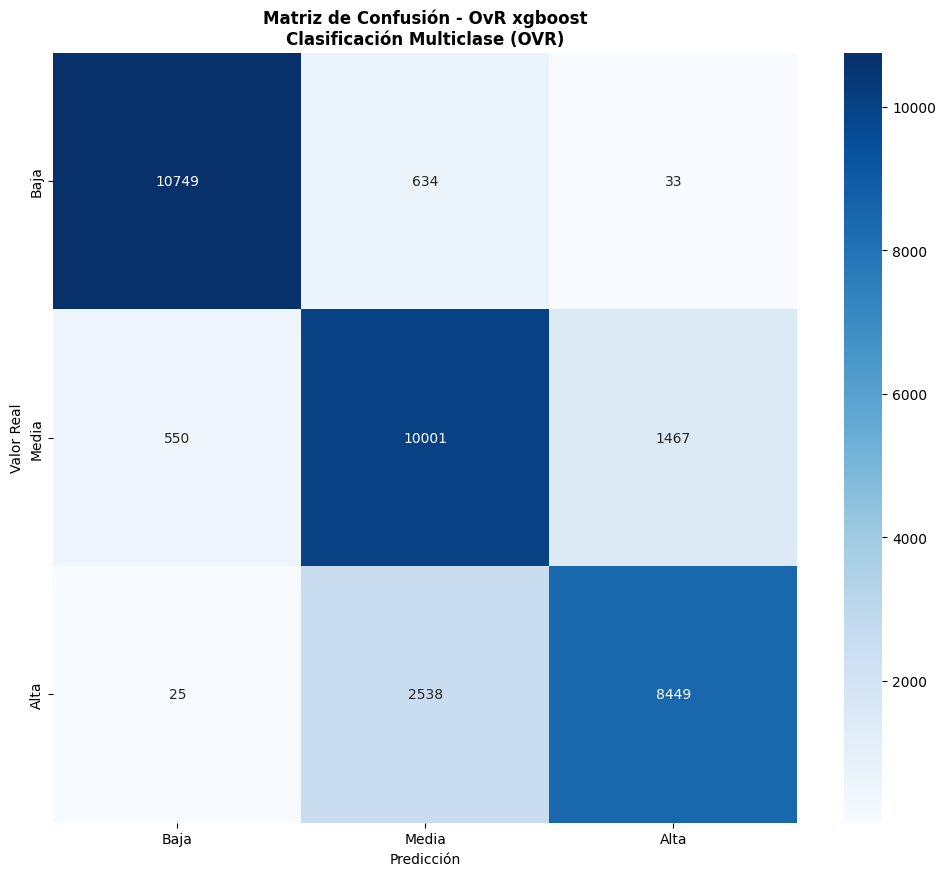

              precision    recall  f1-score   support

        Baja     0.8295    0.7571    0.7916     11416
       Media     0.7167    0.5156    0.5997     12018
        Alta     0.5751    0.8032    0.6703     11012

    accuracy                         0.6876     34446
   macro avg     0.7071    0.6920    0.6872     34446
weighted avg     0.7088    0.6876    0.6859     34446



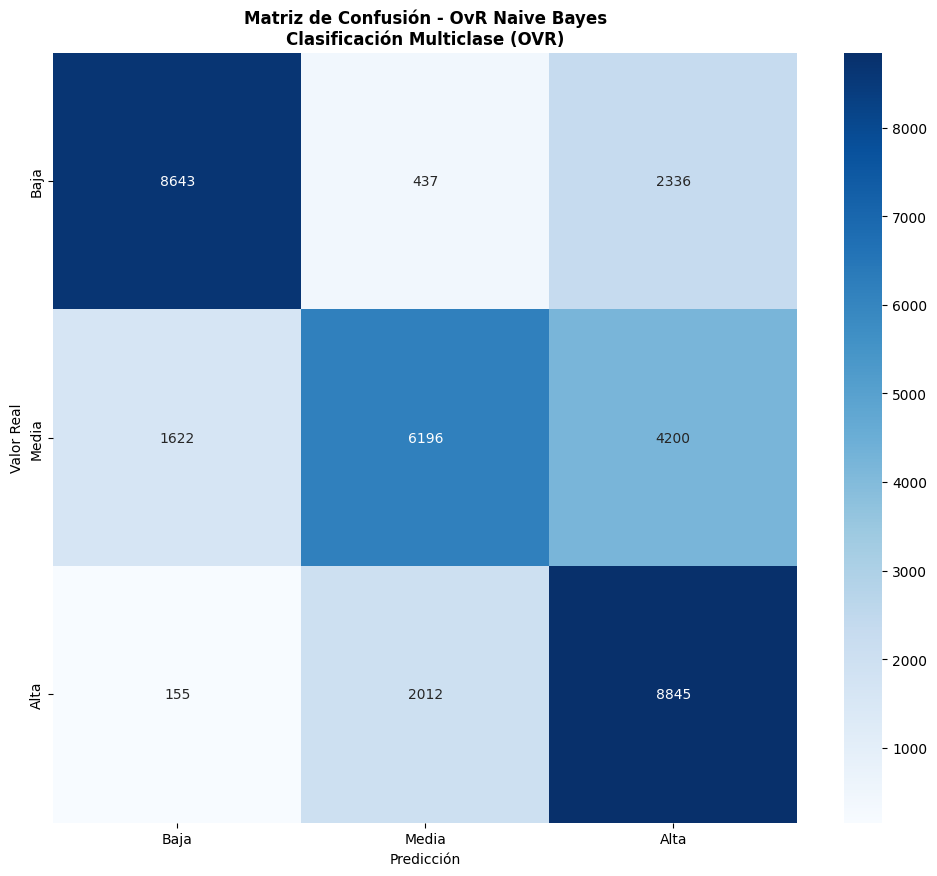

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.6632, F1: 0.6581, Clasificadores: 5
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.7309, F1: 0.7315, Clasificadores: 5
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.7486, F1: 0.7485, Clasificadores: 5
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.7225, F1: 0.7229, Clasificadores: 5
Entrenando OvR xgboost...
   Completado - Accuracy: 0.7476, F1: 0.7479, Clasificadores: 5
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.5389, F1: 0.5391, Clasificadores: 5

RESULTADOS OvR - MULTICLASE (5 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.7486     0.7510  0.7486    0.7485   
1              OvR xgboost    0.7476     0.7530  0.7476    0.7479   
2        OvR Decision Tree    0.7309     0.7393  0.7309    0.7315   
3    OvR Gradient Boosting    0.7225     0.7284  0.7225    0.7229   
4  OvR Logistic Regression    0.663

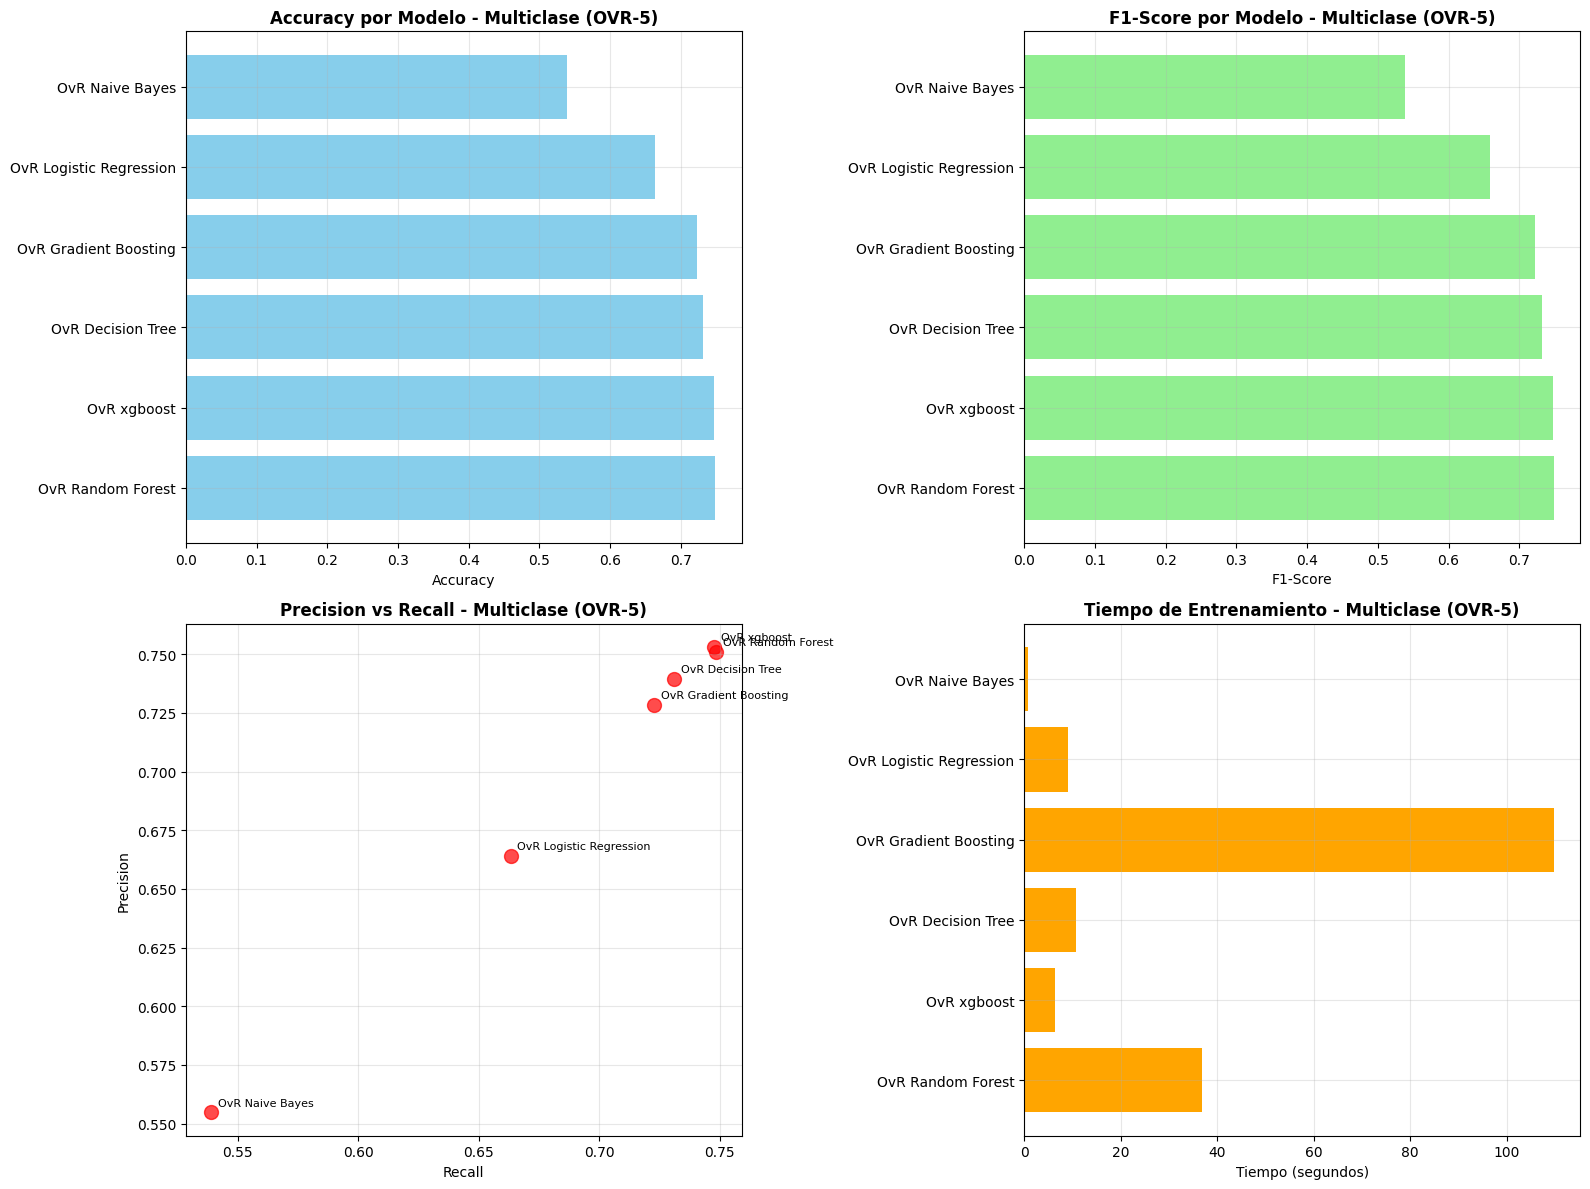

              precision    recall  f1-score   support

    Muy Baja     0.7951    0.9318    0.8580      7946
        Baja     0.6197    0.5324    0.5727      5836
       Media     0.5260    0.6646    0.5873      6918
        Alta     0.5622    0.4539    0.5023      6861
    Muy Alta     0.7911    0.6710    0.7261      6885

    accuracy                         0.6632     34446
   macro avg     0.6588    0.6507    0.6493     34446
weighted avg     0.6641    0.6632    0.6581     34446



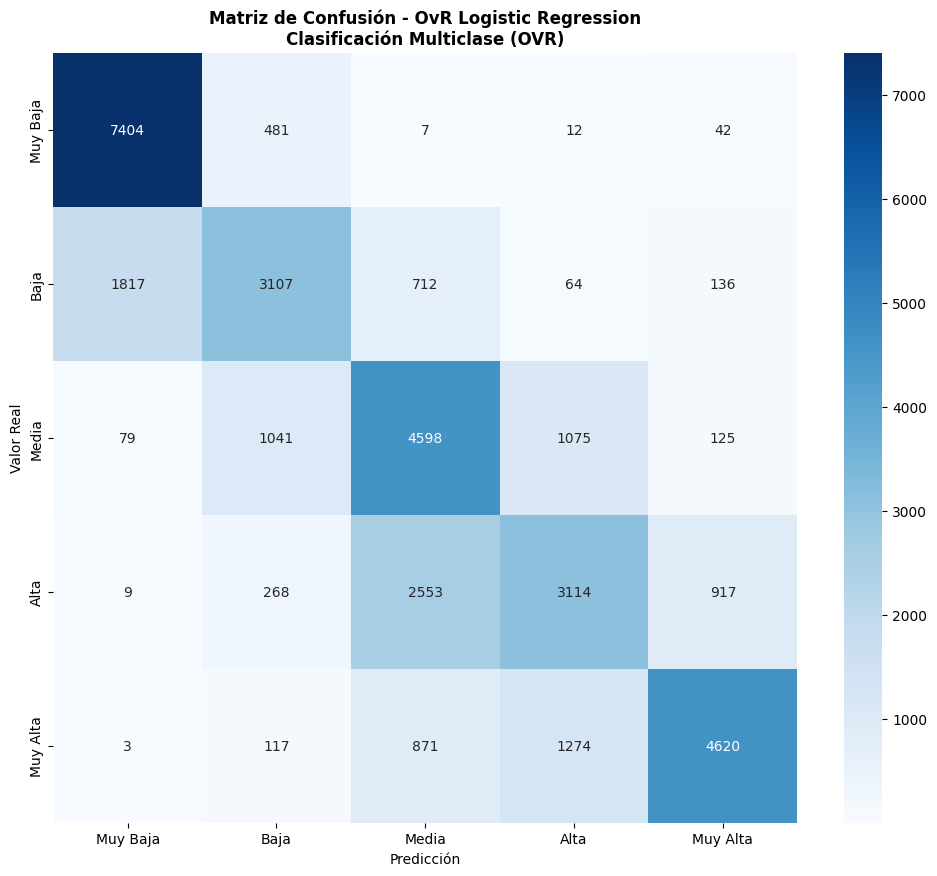

              precision    recall  f1-score   support

    Muy Baja     0.9229    0.9349    0.9289      7946
        Baja     0.7038    0.8089    0.7527      5836
       Media     0.5951    0.6542    0.6233      6918
        Alta     0.5853    0.5807    0.5830      6861
    Muy Alta     0.8558    0.6558    0.7425      6885

    accuracy                         0.7309     34446
   macro avg     0.7326    0.7269    0.7261     34446
weighted avg     0.7393    0.7309    0.7315     34446



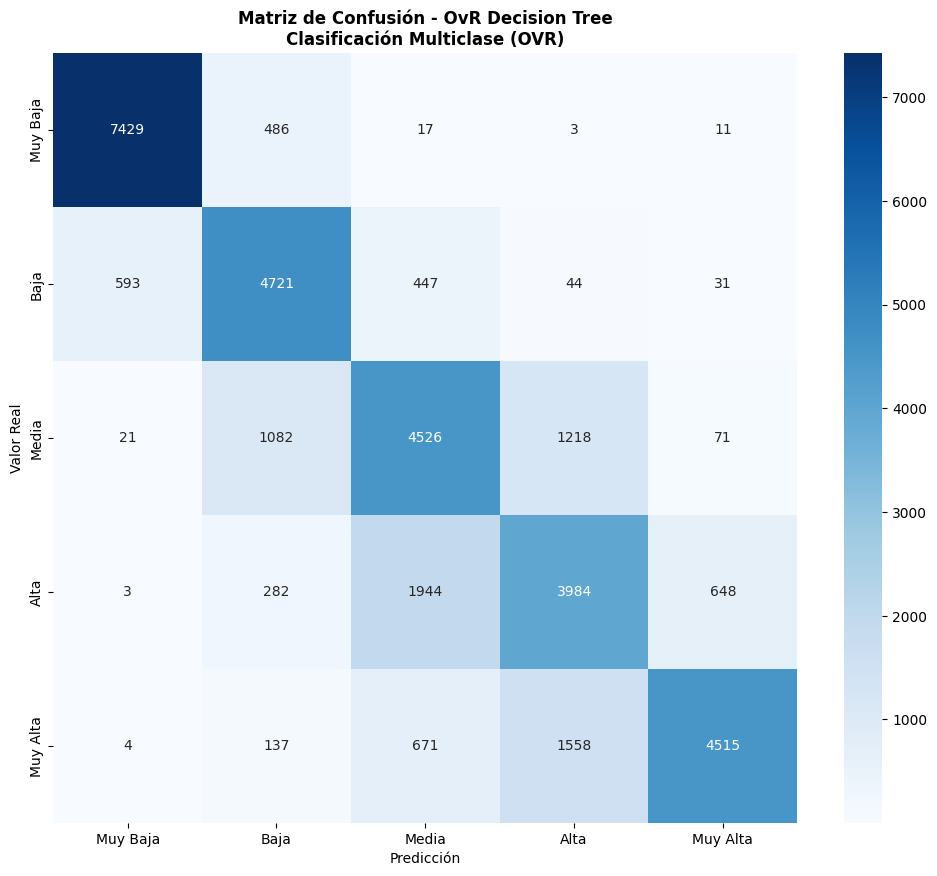

              precision    recall  f1-score   support

    Muy Baja     0.9352    0.9523    0.9437      7946
        Baja     0.7640    0.8143    0.7883      5836
       Media     0.6158    0.6732    0.6432      6918
        Alta     0.5983    0.5791    0.5885      6861
    Muy Alta     0.8152    0.7024    0.7546      6885

    accuracy                         0.7486     34446
   macro avg     0.7457    0.7442    0.7437     34446
weighted avg     0.7510    0.7486    0.7485     34446



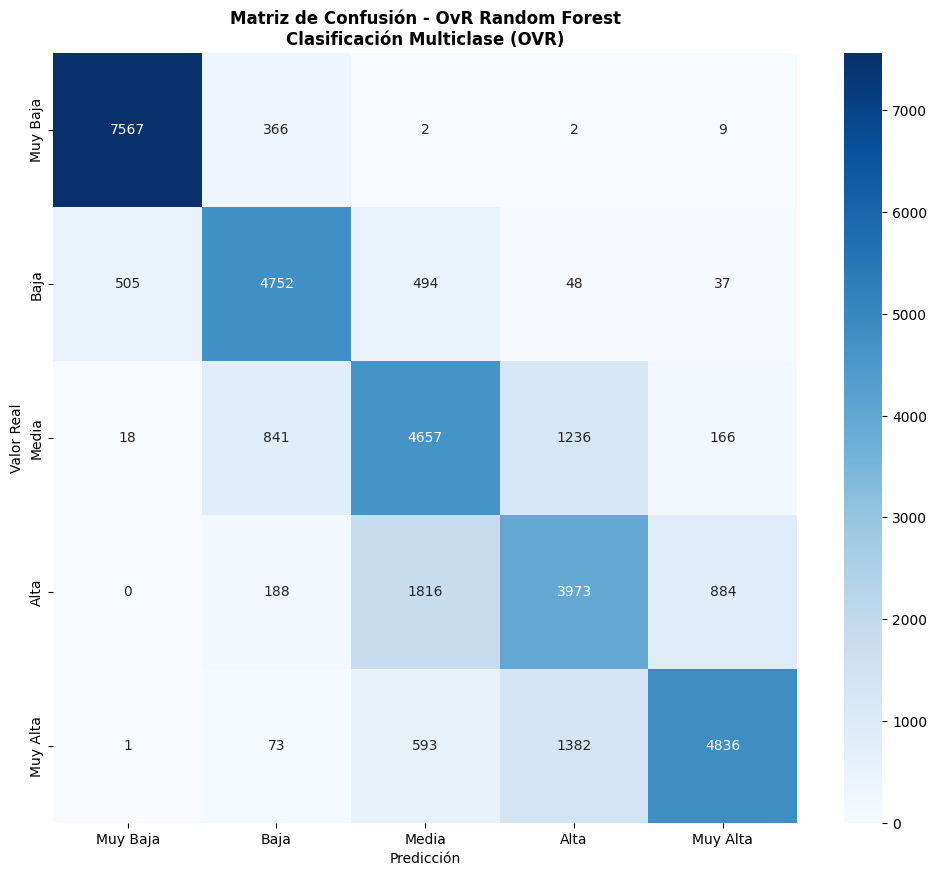

              precision    recall  f1-score   support

    Muy Baja     0.9127    0.9232    0.9179      7946
        Baja     0.6804    0.7834    0.7283      5836
       Media     0.5900    0.6492    0.6182      6918
        Alta     0.5926    0.5603    0.5760      6861
    Muy Alta     0.8311    0.6747    0.7447      6885

    accuracy                         0.7225     34446
   macro avg     0.7213    0.7181    0.7170     34446
weighted avg     0.7284    0.7225    0.7229     34446



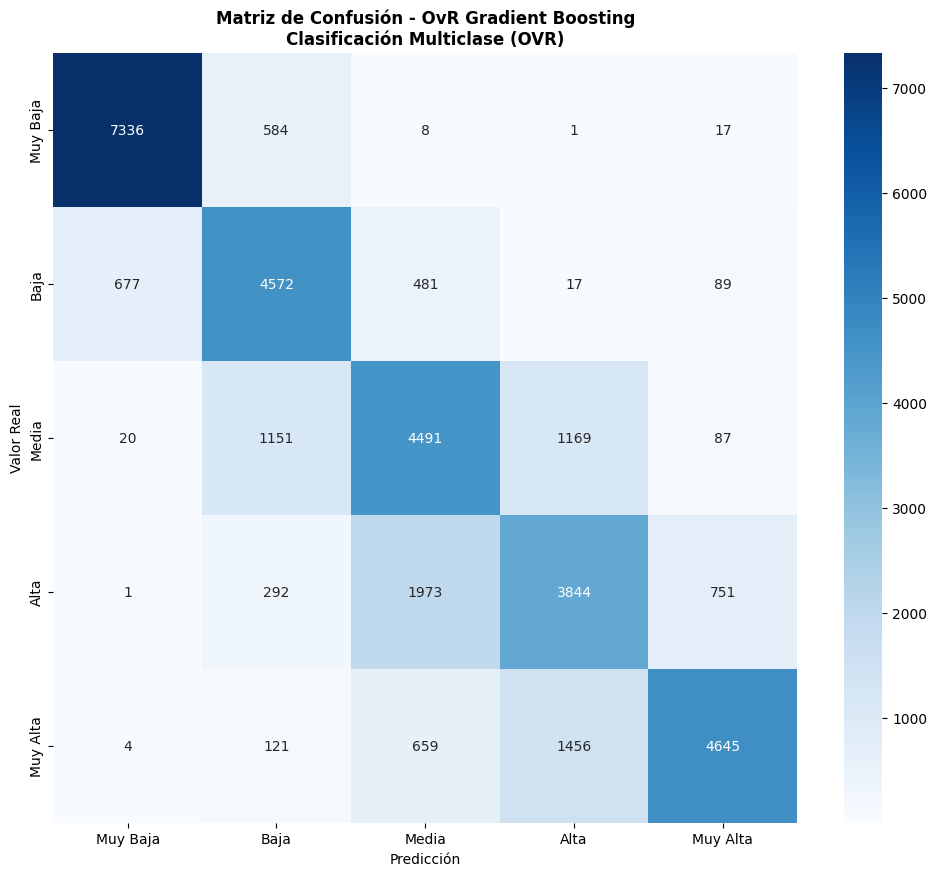

              precision    recall  f1-score   support

    Muy Baja     0.9326    0.9476    0.9401      7946
        Baja     0.7467    0.8144    0.7791      5836
       Media     0.6082    0.6902    0.6466      6918
        Alta     0.6044    0.5769    0.5903      6861
    Muy Alta     0.8448    0.6880    0.7584      6885

    accuracy                         0.7476     34446
   macro avg     0.7474    0.7434    0.7429     34446
weighted avg     0.7530    0.7476    0.7479     34446



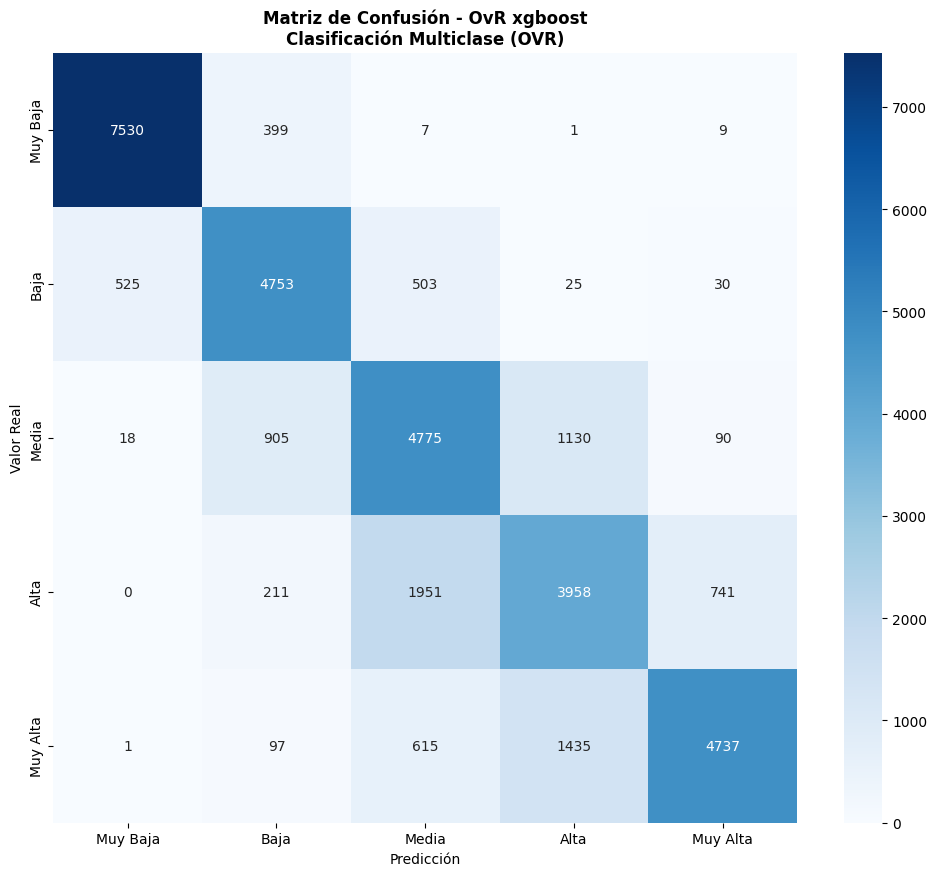

              precision    recall  f1-score   support

    Muy Baja     0.7775    0.6345    0.6988      7946
        Baja     0.4784    0.4659    0.4721      5836
       Media     0.5207    0.3604    0.4259      6918
        Alta     0.4478    0.5789    0.5050      6861
    Muy Alta     0.5032    0.6299    0.5595      6885

    accuracy                         0.5389     34446
   macro avg     0.5455    0.5339    0.5322     34446
weighted avg     0.5547    0.5389    0.5391     34446



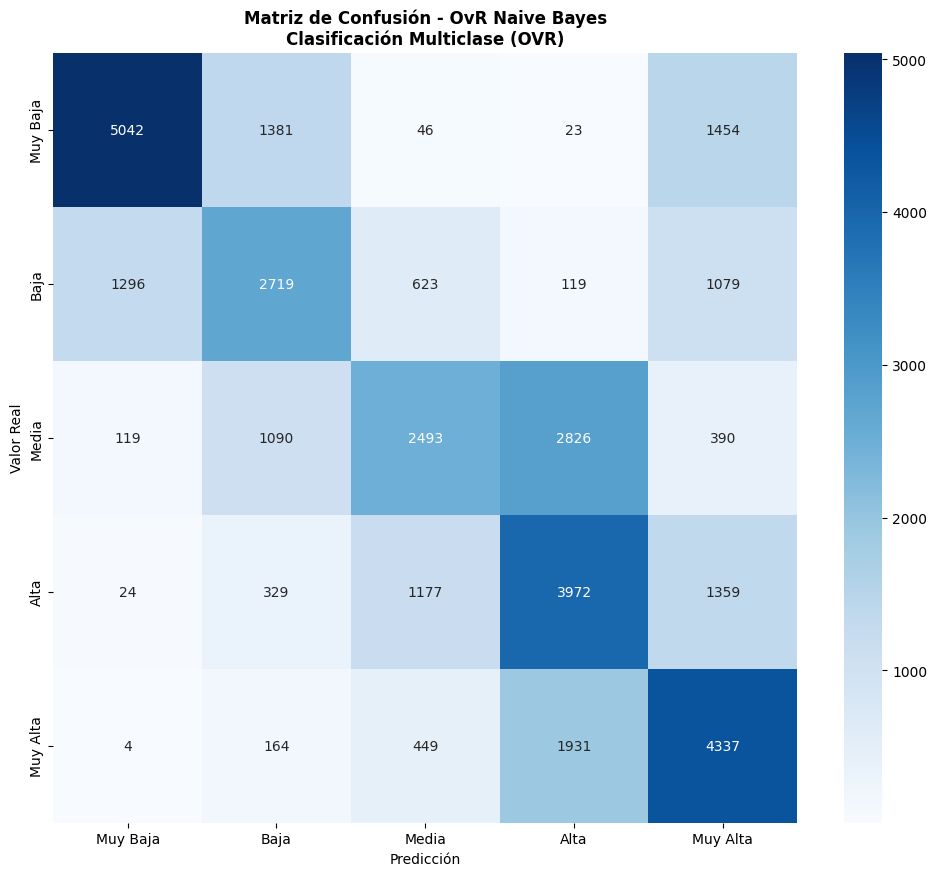


Estrategias OvR completadas


In [167]:
# ESTRATEGIAS ONE-VS-REST (OvR)

ovr_compatible_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
     "xgboost":xgboost.XGBClassifier(random_state=42, objective='binary:logistic'),
    'Naive Bayes': GaussianNB(),
    'xgboost':xgboost.XGBClassifier(objective='binary:logistic')
}


def evaluate_ovr_model(base_model, X_train, X_test, y_train, y_test, model_name, task_type,s):
    """Evalúa un modelo usando estrategia One-vs-Rest"""
    
    ovr_model = OneVsRestClassifier(base_model, n_jobs=-1)
    
    print(f"Entrenando OvR {model_name}...")
    
    
    start_time = time.time()
    ovr_model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    
    start_time = time.time()
    X_test = s.transform(X_test)
    y_pred = ovr_model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': f"OvR {model_name}",
        'strategy': 'OvR',
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': ovr_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'n_classifiers': len(ovr_model.estimators_)
    }
    
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Clasificadores: {len(ovr_model.estimators_)}")
    return results



ovr_multi3_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovr_model(
            base_model=model,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass_3',
            s=scaler1
        )
        ovr_multi3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")


ovr_multi3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovr_multi3_results])

ovr_multi3_df = ovr_multi3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (3 NIVELES):")

print(ovr_multi3_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovr_multi3_df['Recall'], ovr_multi3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovr_multi3_df['Modelo']):
    axes[1,0].annotate(txt, (ovr_multi3_df['Recall'].iloc[i], ovr_multi3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVR)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovr_multi3_results):
    plt.figure(figsize=(12, 10))
    cm = ovr_multi3_results[i]['confusion_matrix']
    name_ = ovr_multi3_results[i]['model_name']
    class_names_5 = [ 'Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, ovr_multi3_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



##########################################################################################################

ovr_multi5_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovr_model(
            base_model=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass_5',
            s=scaler2
        )
        ovr_multi5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")

ovr_multi5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovr_multi5_results])

ovr_multi5_df = ovr_multi5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (5 NIVELES):")
print(ovr_multi5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR-5)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVR-5)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovr_multi5_df['Recall'], ovr_multi5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovr_multi5_df['Modelo']):
    axes[1,0].annotate(txt, (ovr_multi5_df['Recall'].iloc[i], ovr_multi5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVR-5)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR-5)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovr_multi5_results):
    plt.figure(figsize=(12, 10))
    cm = ovr_multi5_results[i]['confusion_matrix']
    name_ = ovr_multi5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, ovr_multi5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



print(f"\nEstrategias OvR completadas")

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.8172, F1: 0.8169, Clasificadores: 3
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.8388, F1: 0.8390, Clasificadores: 3
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.8488, F1: 0.8487, Clasificadores: 3
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.8323, F1: 0.8324, Clasificadores: 3
Entrenando OvR xgboost...
   Completado - Accuracy: 0.8472, F1: 0.8475, Clasificadores: 3
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.6875, F1: 0.6867, Clasificadores: 3

RESULTADOS OvR - MULTICLASE (3 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.8488     0.8504  0.8488    0.8487   
1              OvR xgboost    0.8472     0.8501  0.8472    0.8475   
2        OvR Decision Tree    0.8388     0.8421  0.8388    0.8390   
3    OvR Gradient Boosting    0.8323     0.8351  0.8323    0.8324   
4  OvR Logistic Regression    0.817

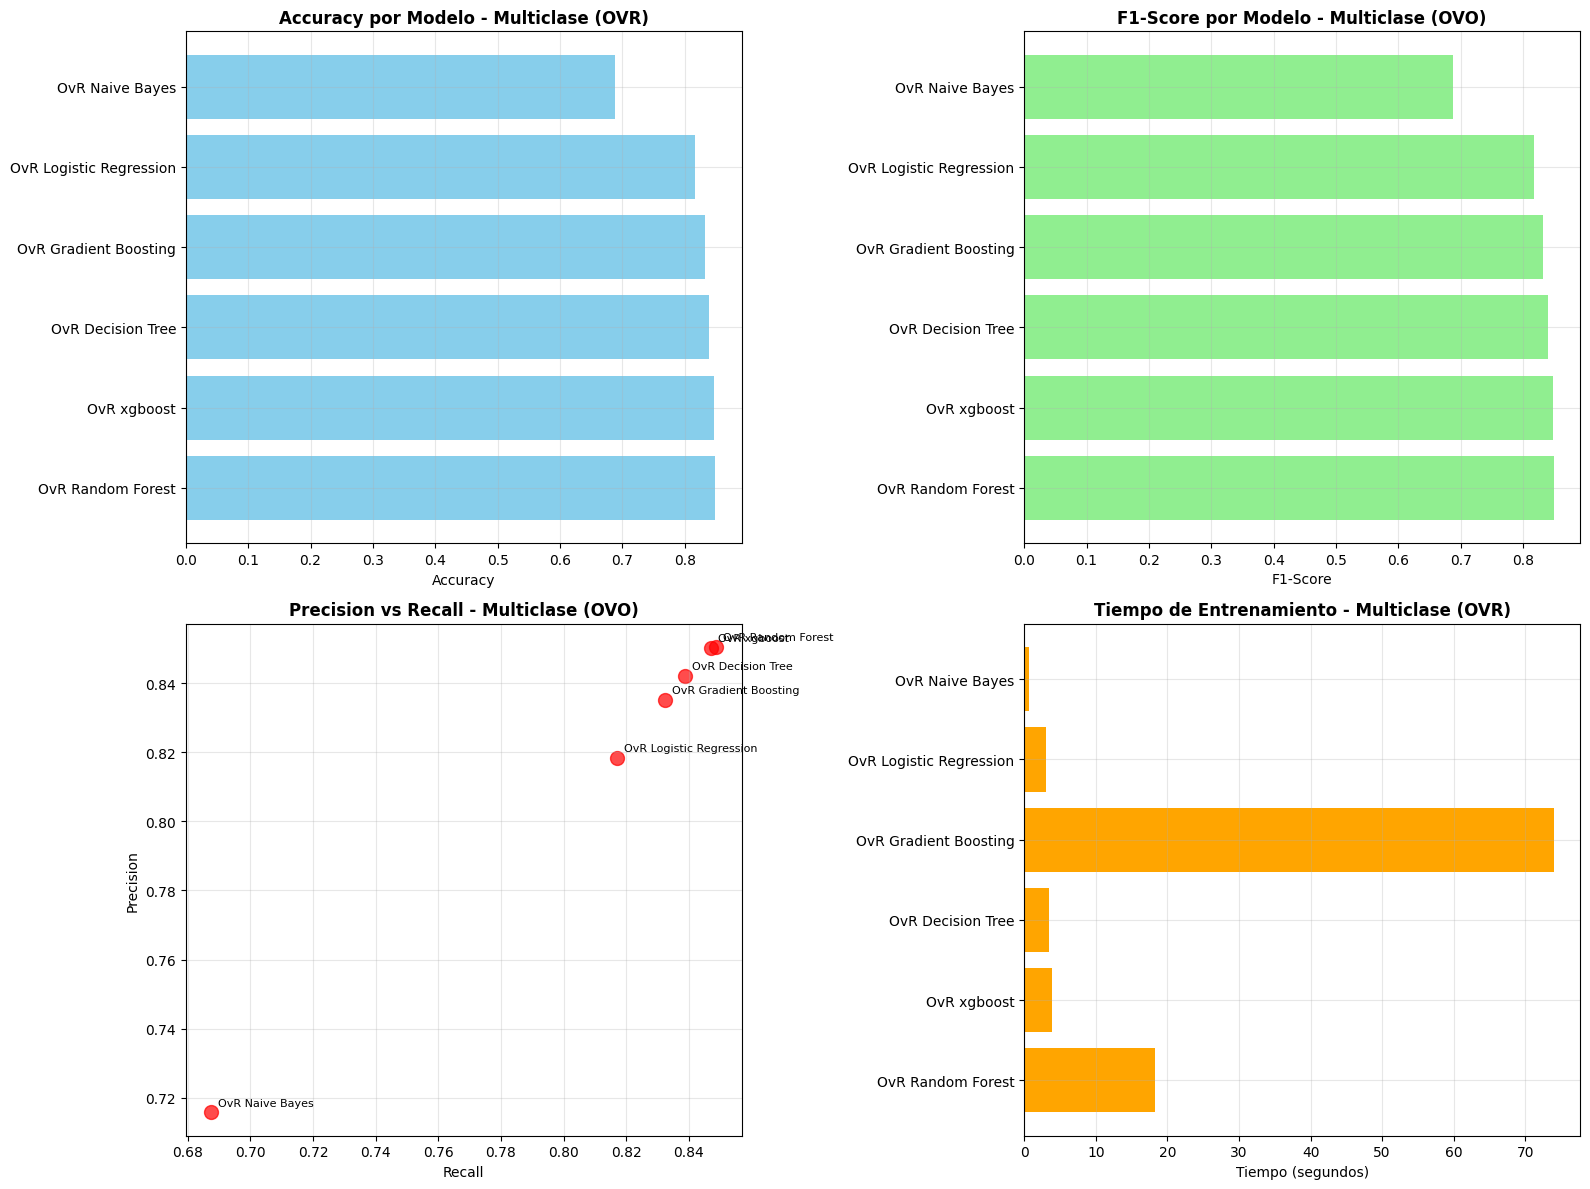

              precision    recall  f1-score   support

        Baja     0.8994    0.9290    0.9140     11416
       Media     0.7301    0.7714    0.7502     12018
        Alta     0.8310    0.7513    0.7891     11012

    accuracy                         0.8172     34446
   macro avg     0.8202    0.8172    0.8178     34446
weighted avg     0.8185    0.8172    0.8169     34446



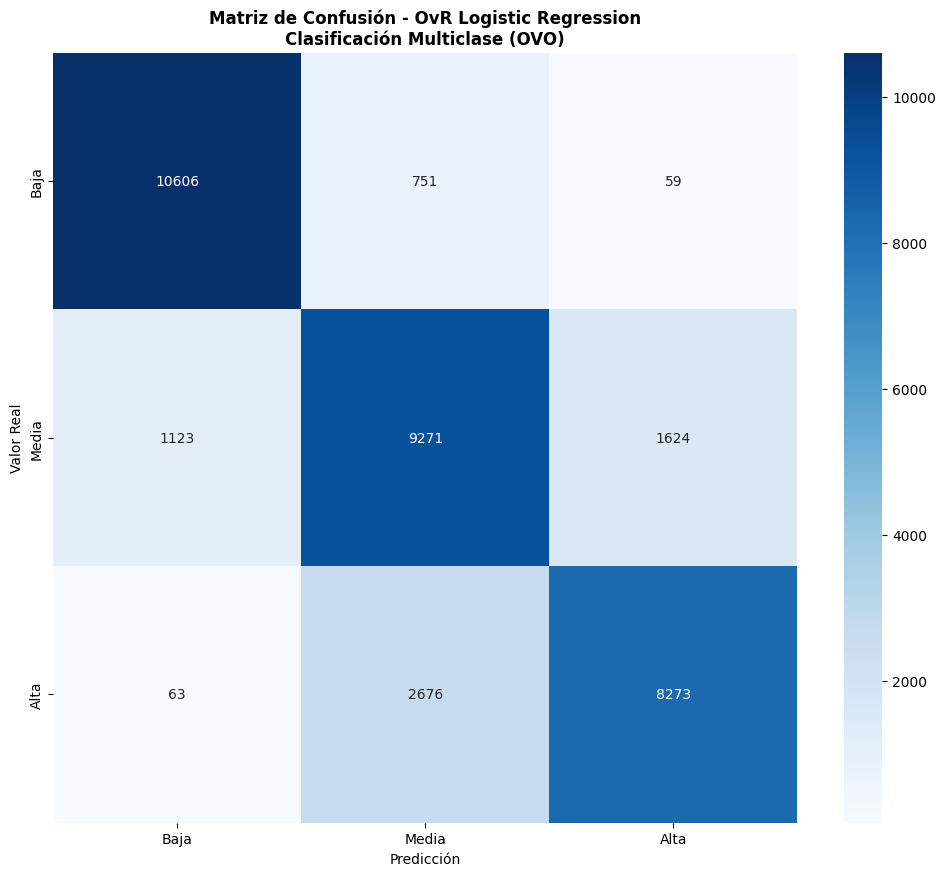

              precision    recall  f1-score   support

        Baja     0.9410    0.9409    0.9410     11416
       Media     0.7476    0.8221    0.7831     12018
        Alta     0.8428    0.7513    0.7944     11012

    accuracy                         0.8388     34446
   macro avg     0.8438    0.8381    0.8395     34446
weighted avg     0.8421    0.8388    0.8390     34446



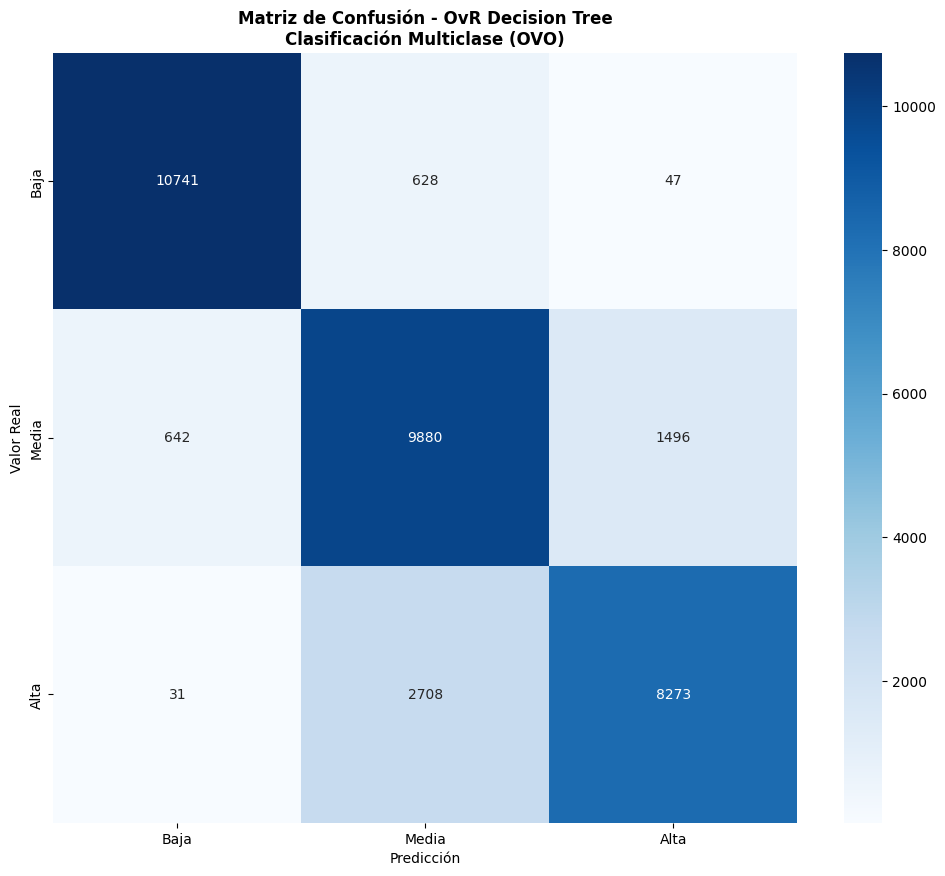

              precision    recall  f1-score   support

        Baja     0.9431    0.9530    0.9480     11416
       Media     0.7668    0.8215    0.7932     12018
        Alta     0.8455    0.7705    0.8063     11012

    accuracy                         0.8488     34446
   macro avg     0.8518    0.8483    0.8492     34446
weighted avg     0.8504    0.8488    0.8487     34446



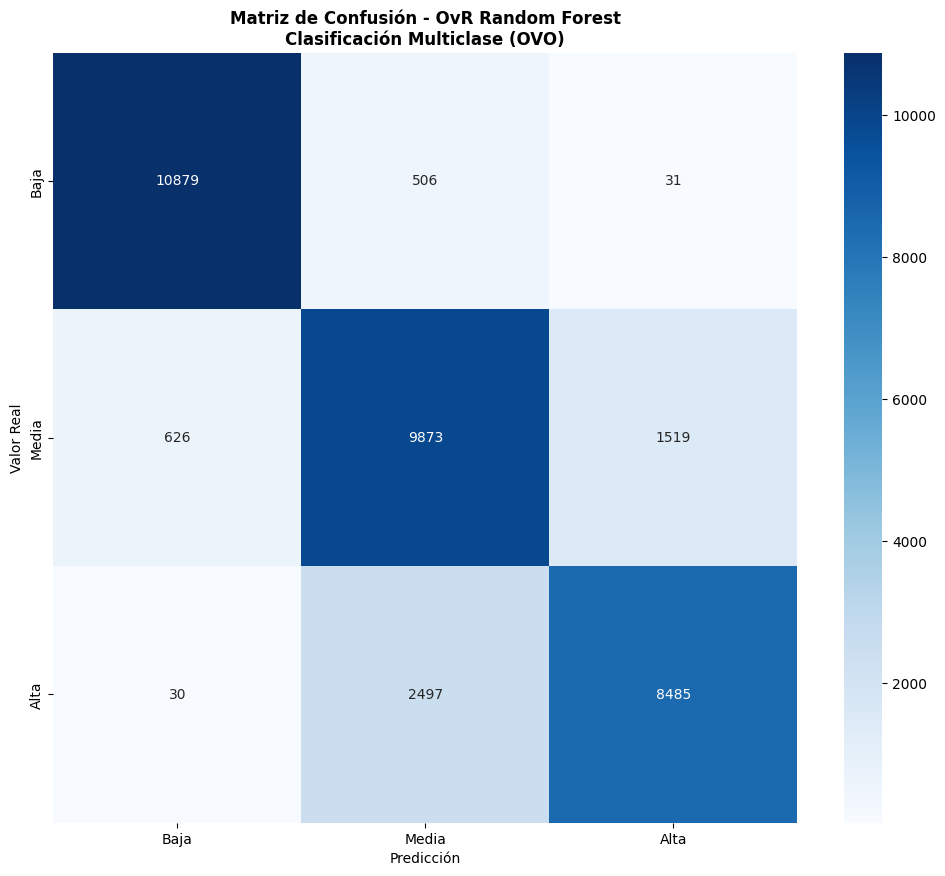

              precision    recall  f1-score   support

        Baja     0.9266    0.9361    0.9313     11416
       Media     0.7420    0.8075    0.7734     12018
        Alta     0.8418    0.7518    0.7943     11012

    accuracy                         0.8323     34446
   macro avg     0.8368    0.8318    0.8330     34446
weighted avg     0.8351    0.8323    0.8324     34446



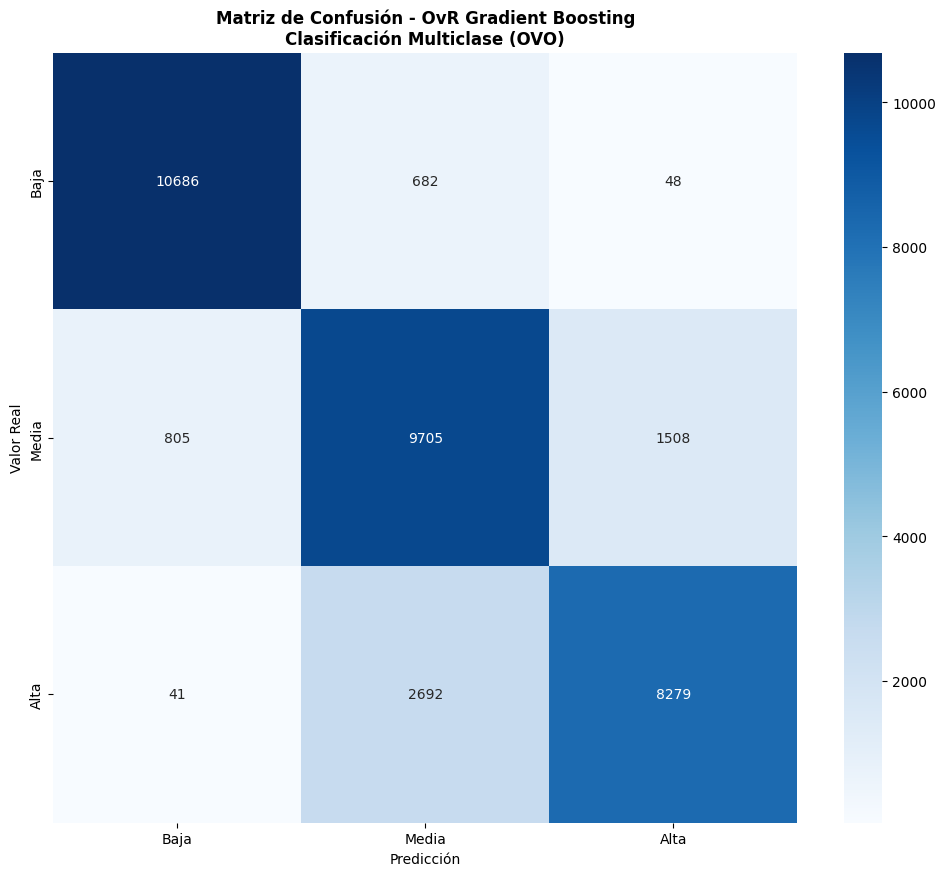

              precision    recall  f1-score   support

        Baja     0.9482    0.9437    0.9459     11416
       Media     0.7597    0.8282    0.7925     12018
        Alta     0.8470    0.7679    0.8055     11012

    accuracy                         0.8472     34446
   macro avg     0.8516    0.8466    0.8480     34446
weighted avg     0.8501    0.8472    0.8475     34446



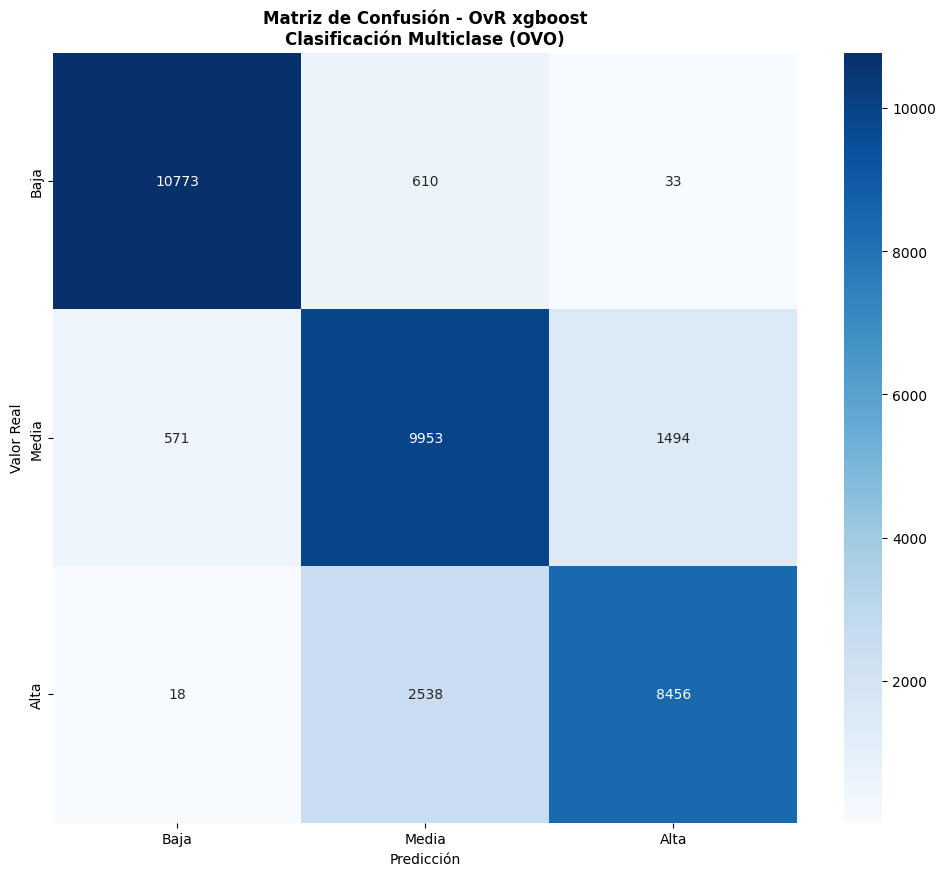

              precision    recall  f1-score   support

        Baja     0.8618    0.7442    0.7987     11416
       Media     0.7150    0.5111    0.5961     12018
        Alta     0.5653    0.8212    0.6696     11012

    accuracy                         0.6875     34446
   macro avg     0.7140    0.6922    0.6881     34446
weighted avg     0.7158    0.6875    0.6867     34446



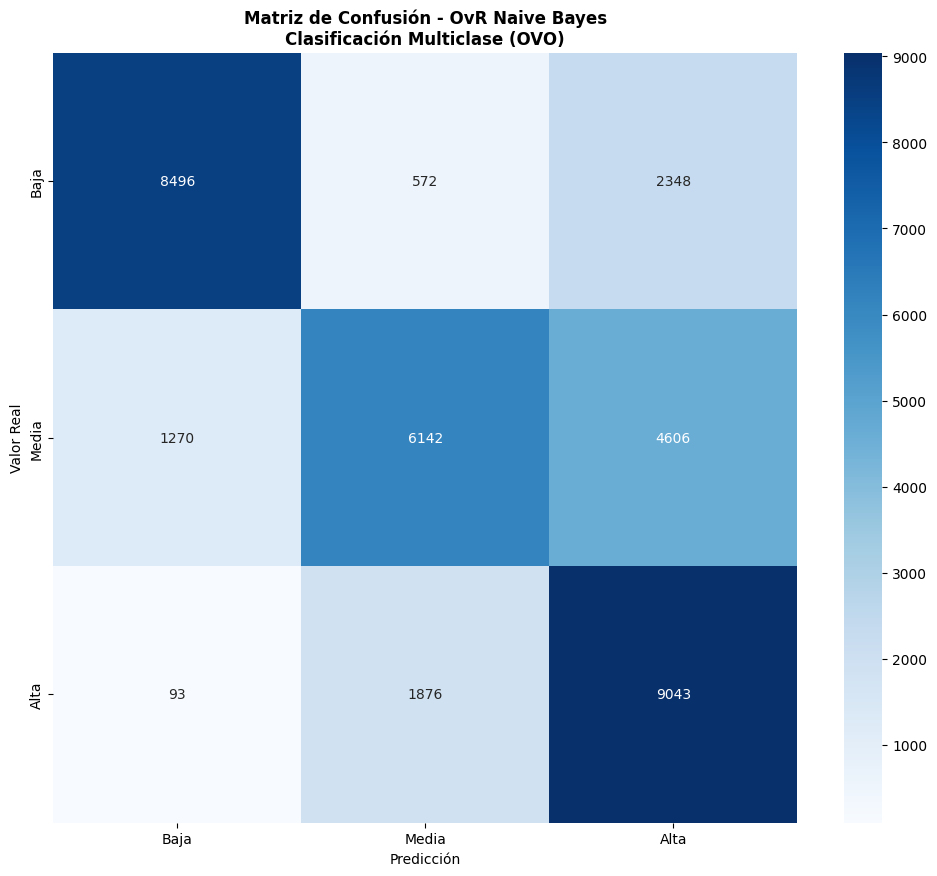

Entrenando OvR Logistic Regression...
   Completado - Accuracy: 0.6911, F1: 0.6900, Clasificadores: 10
Entrenando OvR Decision Tree...
   Completado - Accuracy: 0.7284, F1: 0.7298, Clasificadores: 10
Entrenando OvR Random Forest...
   Completado - Accuracy: 0.7494, F1: 0.7494, Clasificadores: 10
Entrenando OvR Gradient Boosting...
   Completado - Accuracy: 0.7273, F1: 0.7282, Clasificadores: 10
Entrenando OvR xgboost...
   Completado - Accuracy: 0.7461, F1: 0.7464, Clasificadores: 10
Entrenando OvR Naive Bayes...
   Completado - Accuracy: 0.5077, F1: 0.5056, Clasificadores: 10

RESULTADOS OvR - MULTICLASE (5 NIVELES):
                    Modelo  Accuracy  Precision  Recall  F1-Score  \
0        OvR Random Forest    0.7494     0.7530  0.7494    0.7494   
1              OvR xgboost    0.7461     0.7503  0.7461    0.7464   
2        OvR Decision Tree    0.7284     0.7377  0.7284    0.7298   
3    OvR Gradient Boosting    0.7273     0.7347  0.7273    0.7282   
4  OvR Logistic Regression   

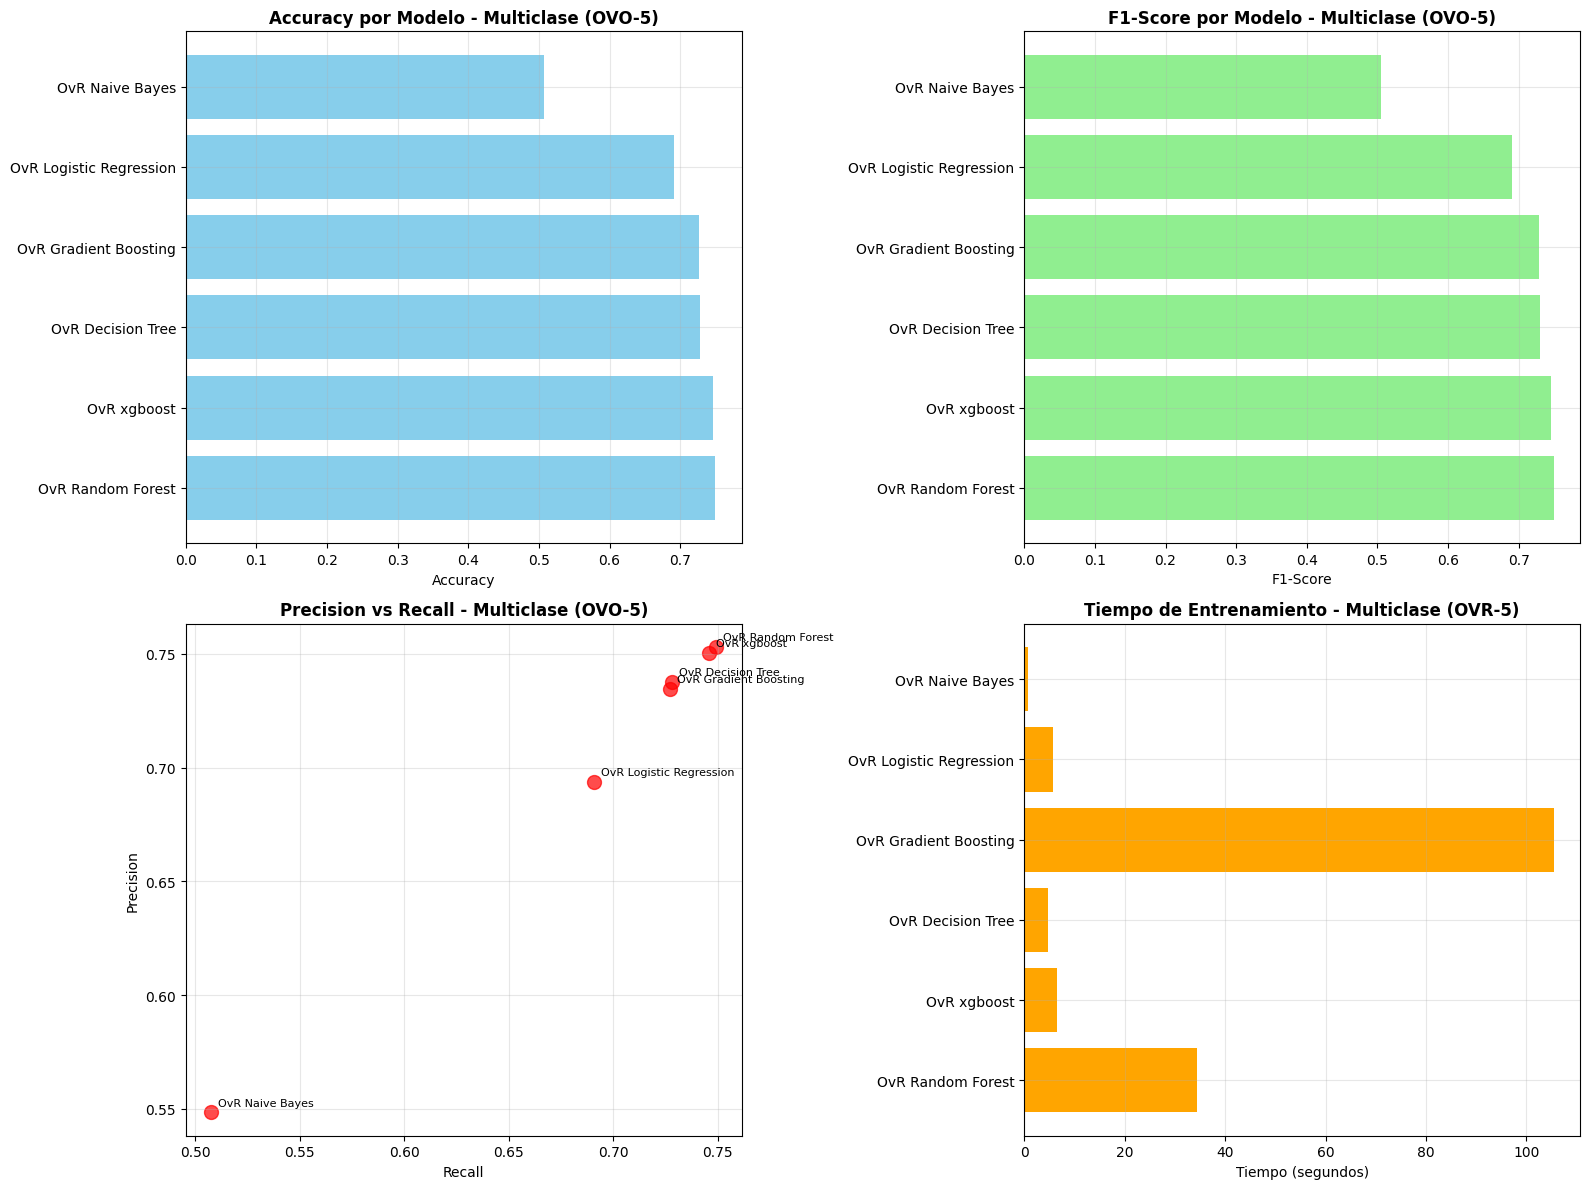

              precision    recall  f1-score   support

    Muy Baja     0.8374    0.9220    0.8776      7946
        Baja     0.6533    0.6268    0.6398      5836
       Media     0.5713    0.6502    0.6082      6918
        Alta     0.5658    0.5374    0.5512      6861
    Muy Alta     0.8125    0.6736    0.7366      6885

    accuracy                         0.6911     34446
   macro avg     0.6881    0.6820    0.6827     34446
weighted avg     0.6937    0.6911    0.6900     34446



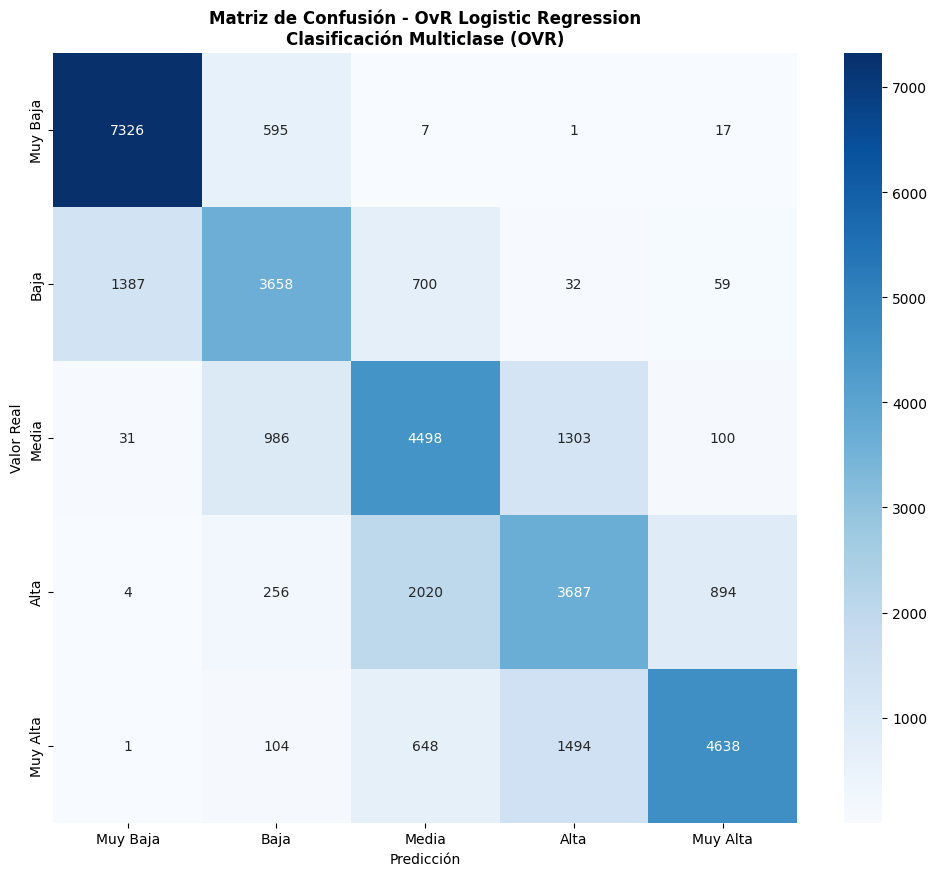

              precision    recall  f1-score   support

    Muy Baja     0.9263    0.9368    0.9315      7946
        Baja     0.7238    0.7870    0.7541      5836
       Media     0.5845    0.6552    0.6178      6918
        Alta     0.5733    0.5861    0.5796      6861
    Muy Alta     0.8496    0.6533    0.7386      6885

    accuracy                         0.7284     34446
   macro avg     0.7315    0.7237    0.7243     34446
weighted avg     0.7377    0.7284    0.7298     34446



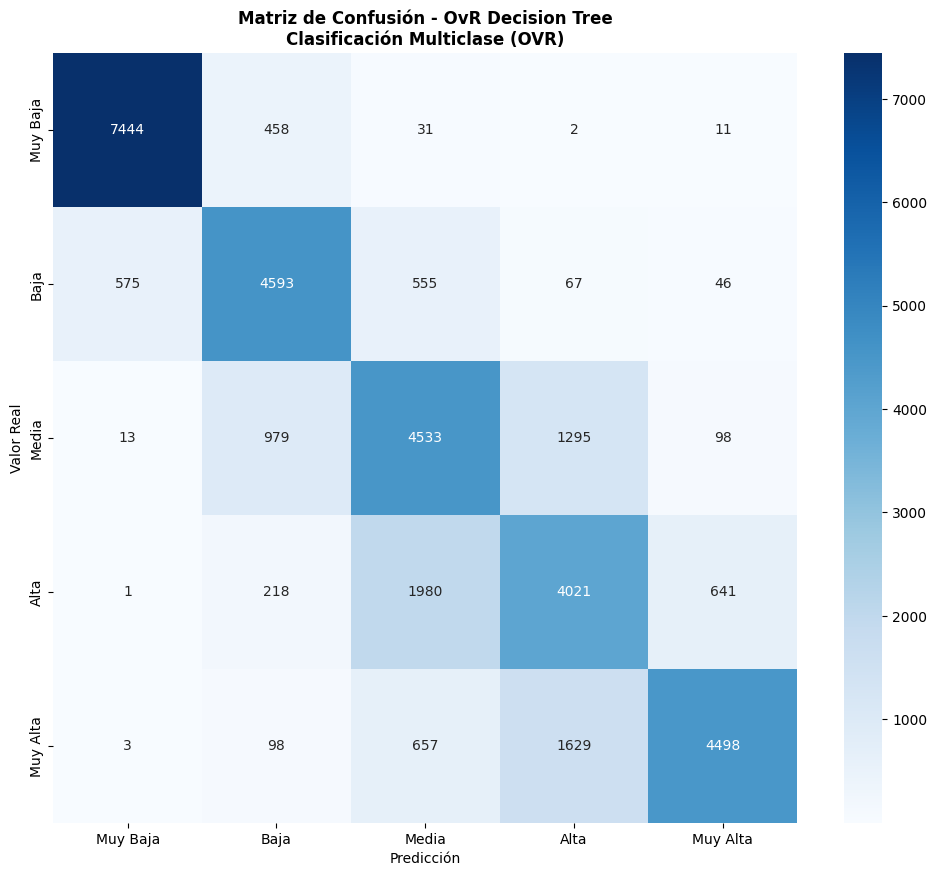

              precision    recall  f1-score   support

    Muy Baja     0.9341    0.9531    0.9435      7946
        Baja     0.7636    0.8153    0.7886      5836
       Media     0.6164    0.6882    0.6503      6918
        Alta     0.6004    0.5804    0.5902      6861
    Muy Alta     0.8242    0.6886    0.7503      6885

    accuracy                         0.7494     34446
   macro avg     0.7478    0.7451    0.7446     34446
weighted avg     0.7530    0.7494    0.7494     34446



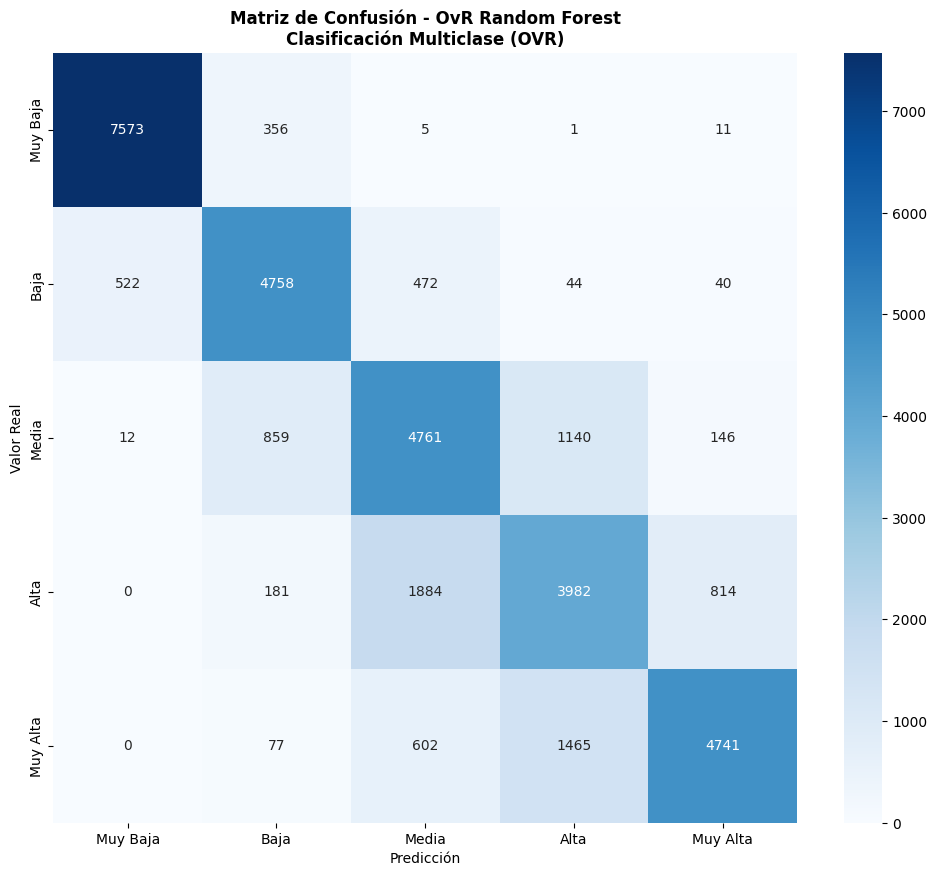

              precision    recall  f1-score   support

    Muy Baja     0.9200    0.9220    0.9210      7946
        Baja     0.6956    0.7851    0.7377      5836
       Media     0.5875    0.6680    0.6251      6918
        Alta     0.5967    0.5646    0.5802      6861
    Muy Alta     0.8395    0.6752    0.7485      6885

    accuracy                         0.7273     34446
   macro avg     0.7279    0.7230    0.7225     34446
weighted avg     0.7347    0.7273    0.7282     34446



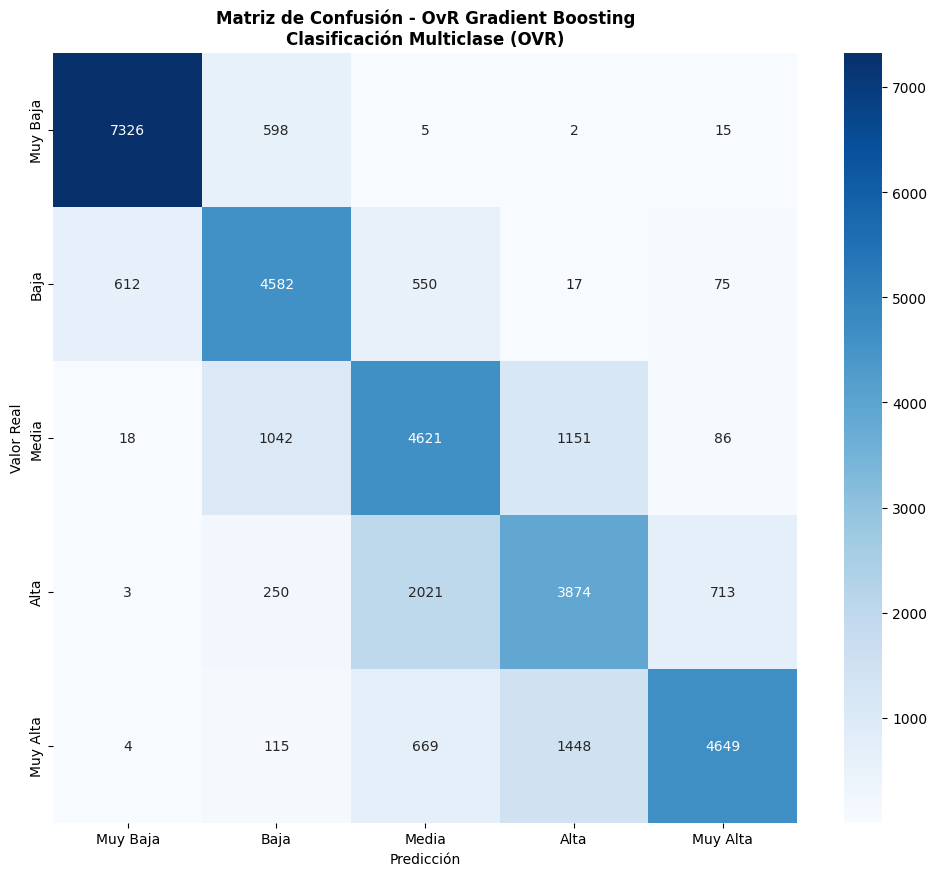

              precision    recall  f1-score   support

    Muy Baja     0.9361    0.9476    0.9418      7946
        Baja     0.7589    0.8064    0.7819      5836
       Media     0.6063    0.6886    0.6448      6918
        Alta     0.5996    0.5716    0.5853      6861
    Muy Alta     0.8237    0.6941    0.7534      6885

    accuracy                         0.7461     34446
   macro avg     0.7449    0.7417    0.7414     34446
weighted avg     0.7503    0.7461    0.7464     34446



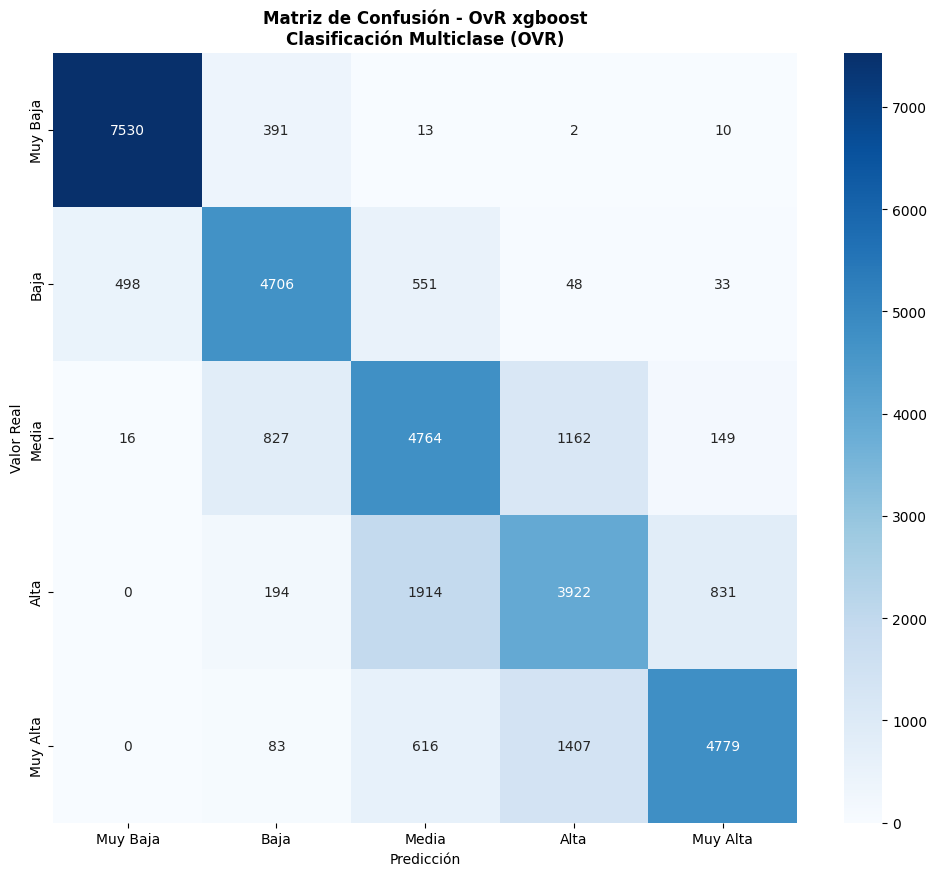

              precision    recall  f1-score   support

    Muy Baja     0.7982    0.4544    0.5791      7946
        Baja     0.4141    0.5423    0.4696      5836
       Media     0.5159    0.3053    0.3836      6918
        Alta     0.4381    0.6447    0.5217      6861
    Muy Alta     0.5164    0.6067    0.5579      6885

    accuracy                         0.5077     34446
   macro avg     0.5365    0.5107    0.5024     34446
weighted avg     0.5484    0.5077    0.5056     34446



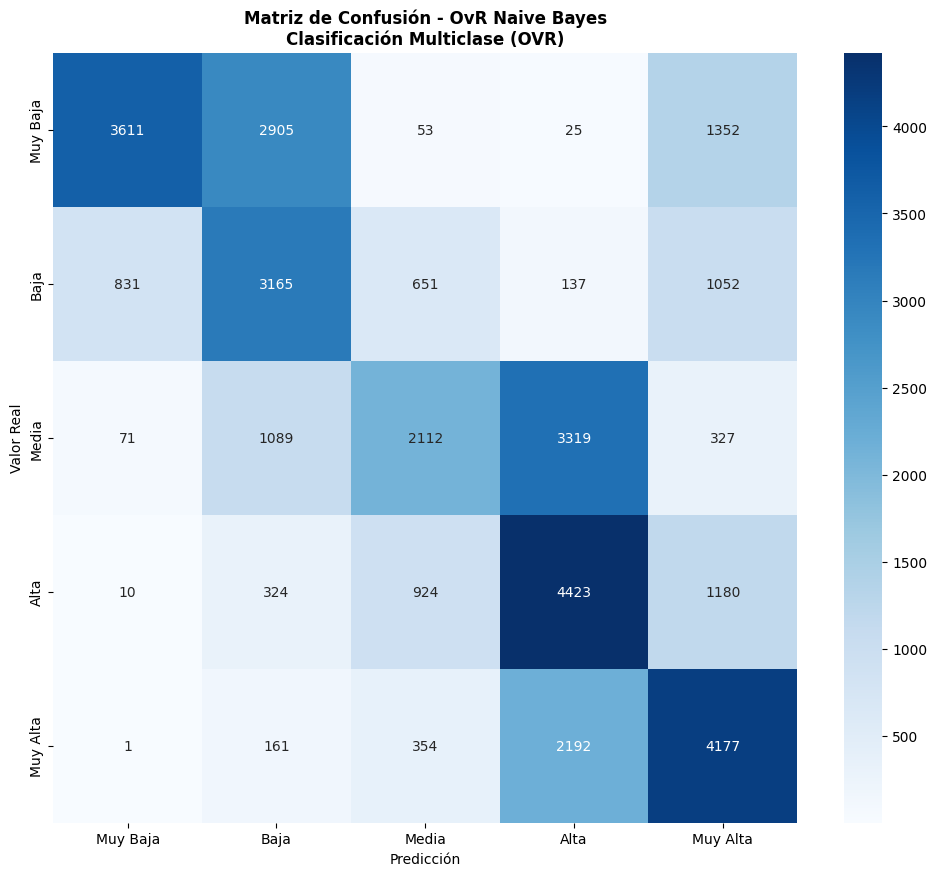


Estrategias OvR completadas


In [168]:
# ESTRATEGIAS ONE-VS-REST (OvO)

ovo_compatible_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Naive Bayes': GaussianNB(),
    'xgboost':xgboost.XGBClassifier(objective='binary:logistic')
}


def evaluate_ovo_model(base_model, X_train, X_test, y_train, y_test, model_name, task_type,sc):
    """Evalúa un modelo usando estrategia One-vs-One"""
    
    ovr_model = OneVsOneClassifier(base_model, n_jobs=-1)
    
    print(f"Entrenando OvR {model_name}...")
    
    
    start_time = time.time()
    ovr_model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    
    start_time = time.time()
    X_test = sc.transform(X_test)
    y_pred = ovr_model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': f"OvR {model_name}",
        'strategy': 'OvR',
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': ovr_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'n_classifiers': len(ovr_model.estimators_)
    }
    
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Clasificadores: {len(ovr_model.estimators_)}")
    return results



ovo_multi3_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovo_model(
            base_model=model,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass_3',
            sc=scaler1
        )
        ovo_multi3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")


ovo_multi3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovo_multi3_results])

ovo_multi3_df = ovo_multi3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (3 NIVELES):")

print(ovo_multi3_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVO)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovo_multi3_df['Recall'], ovo_multi3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovo_multi3_df['Modelo']):
    axes[1,0].annotate(txt, (ovo_multi3_df['Recall'].iloc[i], ovo_multi3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVO)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovo_multi3_results):
    plt.figure(figsize=(12, 10))
    cm = ovo_multi3_results[i]['confusion_matrix']
    name_ = ovo_multi3_results[i]['model_name']
    class_names_5 = ['Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVO)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, ovo_multi3_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



##########################################################################################################

ovo_multi5_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        result = evaluate_ovo_model(
            base_model=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass_5',
            sc=scaler2
        )
        ovo_multi5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")

ovo_multi5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'N° Clasificadores': r['n_classifiers'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovo_multi5_results])

ovo_multi5_df = ovo_multi5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (5 NIVELES):")
print(ovo_multi5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVO-5)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVO-5)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovo_multi5_df['Recall'], ovo_multi5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovo_multi5_df['Modelo']):
    axes[1,0].annotate(txt, (ovo_multi5_df['Recall'].iloc[i], ovo_multi5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVO-5)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR-5)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovo_multi5_results):
    plt.figure(figsize=(12, 10))
    cm = ovo_multi5_results[i]['confusion_matrix']
    name_ = ovo_multi5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, ovo_multi5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



print(f"\nEstrategias OvR completadas")

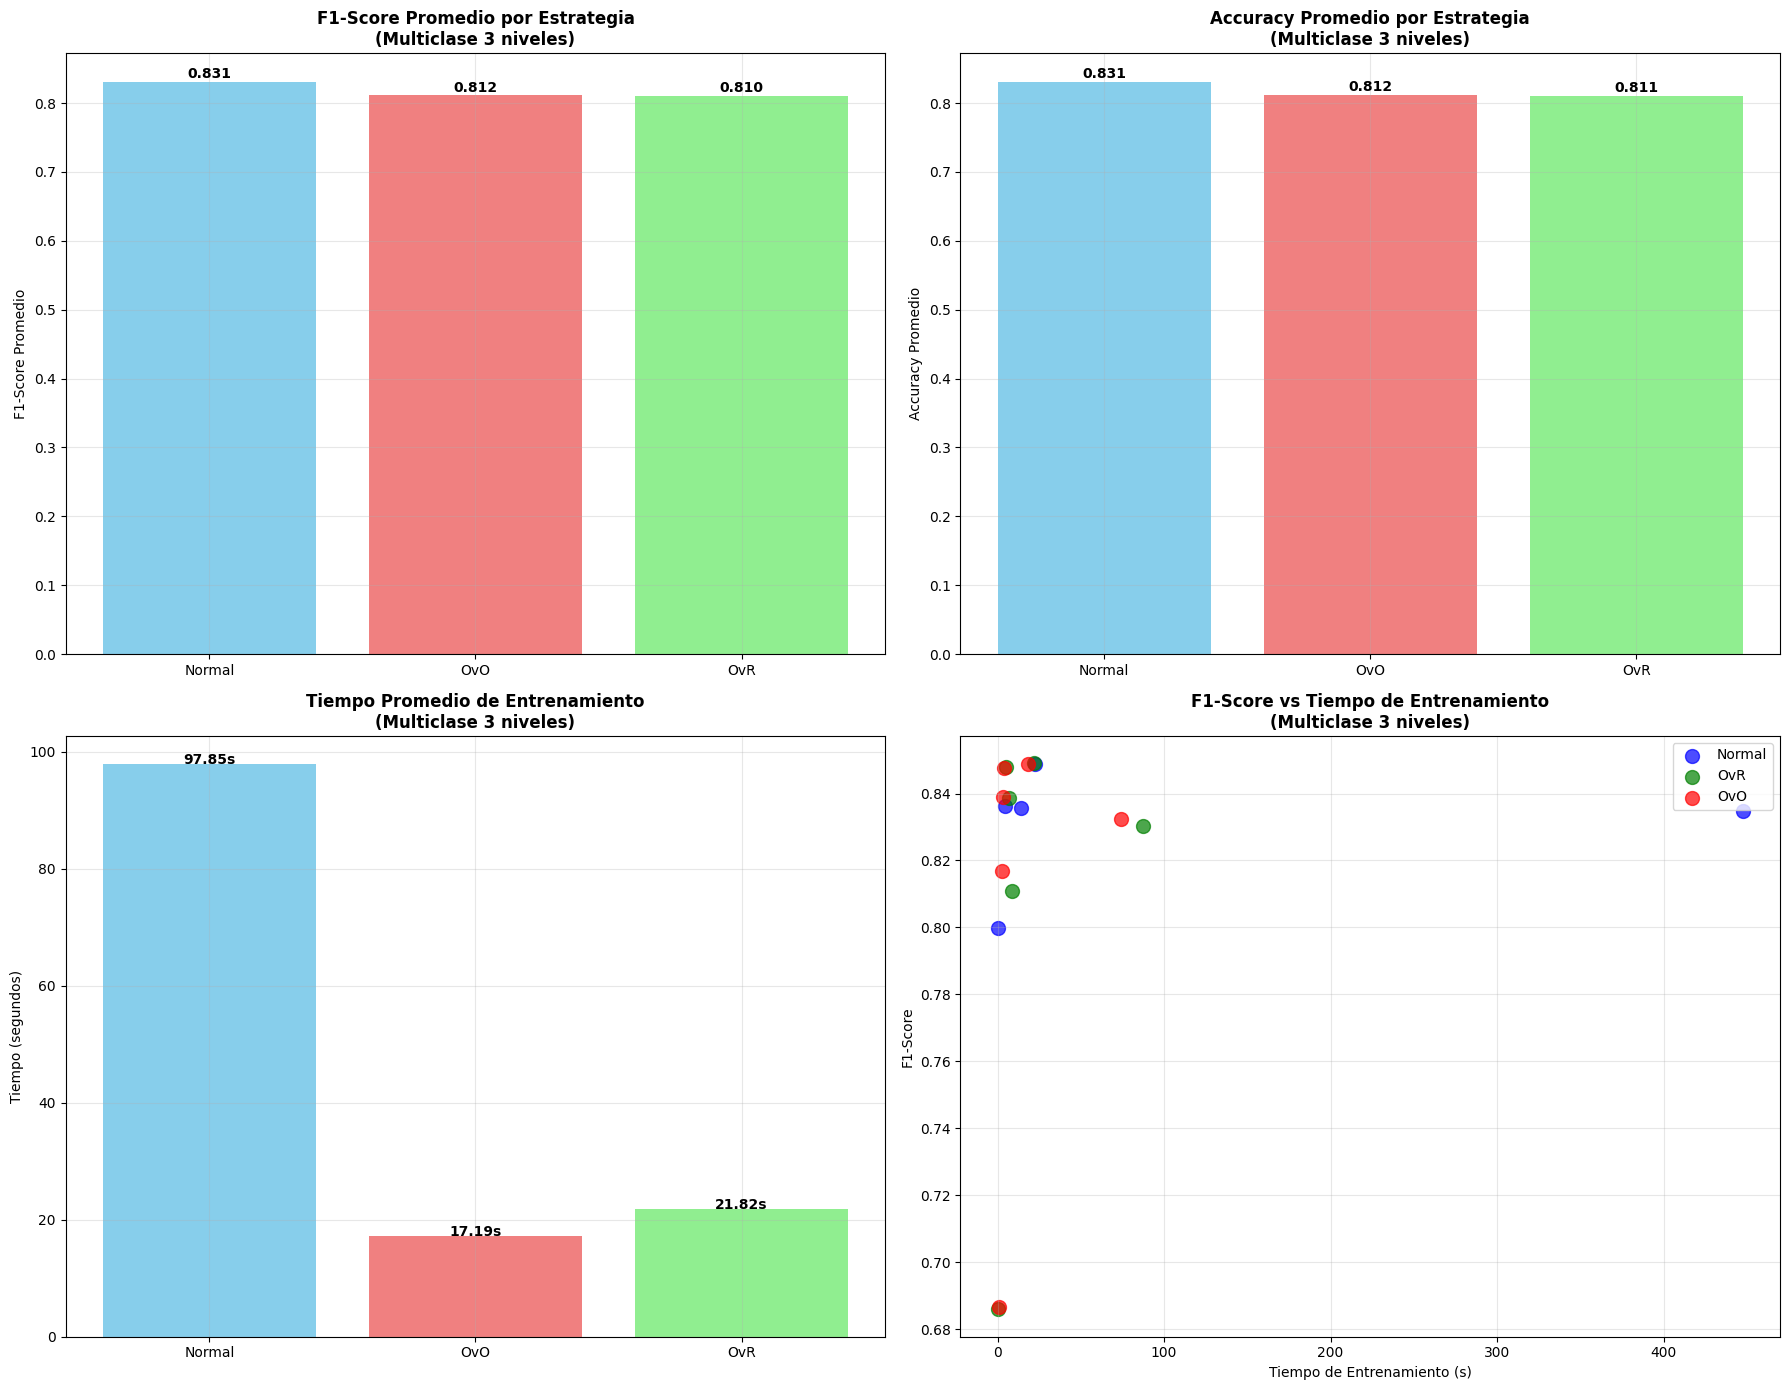

           F1-Score                 Accuracy                  \
               mean     std     max     mean     std     max   
Estrategia                                                     
Normal       0.8311  0.0185  0.8489   0.8309  0.0184  0.8490   
OvO          0.8119  0.0624  0.8487   0.8120  0.0621  0.8488   
OvR          0.8105  0.0626  0.8491   0.8109  0.0619  0.8490   

           Tiempo Entrenamiento            
                           mean       std  
Estrategia                                 
Normal                  97.8453  195.6870  
OvO                     17.1916   28.5069  
OvR                     21.8179   32.8665  

MEJORES MODELOS POR ESTRATEGIA (3 NIVELES):
Normal:
   Modelo: Random Forest
   F1-Score: 0.8489
   Accuracy: 0.8490
   Tiempo: 22.81s

OvR:
   Modelo: Random Forest
   F1-Score: 0.8491
   Accuracy: 0.8490
   Tiempo: 22.12s

OvO:
   Modelo: Random Forest
   F1-Score: 0.8487
   Accuracy: 0.8488
   Tiempo: 18.22s


Comparación completada para clasifi

In [169]:



all_multi3_results = []


for result in multiclass3_results: 
    all_multi3_results.append({
        'Modelo': result['model_name'],
        'Estrategia': 'Normal',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })


for result in ovr_multi3_results:
    all_multi3_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvR',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
for result in ovo_multi3_results:
    all_multi3_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvO',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
comparison_multi3_df = pd.DataFrame(all_multi3_results)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))


strategy_f1_3 = comparison_multi3_df.groupby('Estrategia')['F1-Score'].mean()
axes[0,0].bar(strategy_f1_3.index, strategy_f1_3.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,0].set_title('F1-Score Promedio por Estrategia\n(Multiclase 3 niveles)', fontweight='bold')
axes[0,0].set_ylabel('F1-Score Promedio')
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_f1_3.values):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_acc_3 = comparison_multi3_df.groupby('Estrategia')['Accuracy'].mean()
axes[0,1].bar(strategy_acc_3.index, strategy_acc_3.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,1].set_title('Accuracy Promedio por Estrategia\n(Multiclase 3 niveles)', fontweight='bold')
axes[0,1].set_ylabel('Accuracy Promedio')
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(strategy_acc_3.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_time_3 = comparison_multi3_df.groupby('Estrategia')['Tiempo Entrenamiento'].mean()
axes[1,0].bar(strategy_time_3.index, strategy_time_3.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1,0].set_title('Tiempo Promedio de Entrenamiento\n(Multiclase 3 niveles)', fontweight='bold')
axes[1,0].set_ylabel('Tiempo (segundos)')
axes[1,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_time_3.values):
    axes[1,0].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')


colors_map = {'Normal': 'blue', 'OvO': 'red', 'OvR': 'green'}
for strategy in comparison_multi3_df['Estrategia'].unique():
    data = comparison_multi3_df[comparison_multi3_df['Estrategia'] == strategy]
    axes[1,1].scatter(data['Tiempo Entrenamiento'], data['F1-Score'], 
                     label=strategy, color=colors_map[strategy], s=100, alpha=0.7)

axes[1,1].set_title('F1-Score vs Tiempo de Entrenamiento\n(Multiclase 3 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo de Entrenamiento (s)')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


summary_3_levels = comparison_multi3_df.groupby('Estrategia').agg({
    'F1-Score': ['mean', 'std', 'max'],
    'Accuracy': ['mean', 'std', 'max'],
    'Tiempo Entrenamiento': ['mean', 'std']
}).round(4)

print(summary_3_levels)


print(f"\nMEJORES MODELOS POR ESTRATEGIA (3 NIVELES):")
print("="*50)
for strategy in comparison_multi3_df['Estrategia'].unique():
    best_model = comparison_multi3_df[comparison_multi3_df['Estrategia'] == strategy].loc[
        comparison_multi3_df[comparison_multi3_df['Estrategia'] == strategy]['F1-Score'].idxmax()
    ]
    print(f"{strategy}:")
    print(f"   Modelo: {best_model['Modelo']}")
    print(f"   F1-Score: {best_model['F1-Score']:.4f}")
    print(f"   Accuracy: {best_model['Accuracy']:.4f}")
    print(f"   Tiempo: {best_model['Tiempo Entrenamiento']:.2f}s")
    print()

print(f"\nComparación completada para clasificación multiclase (3 niveles)")

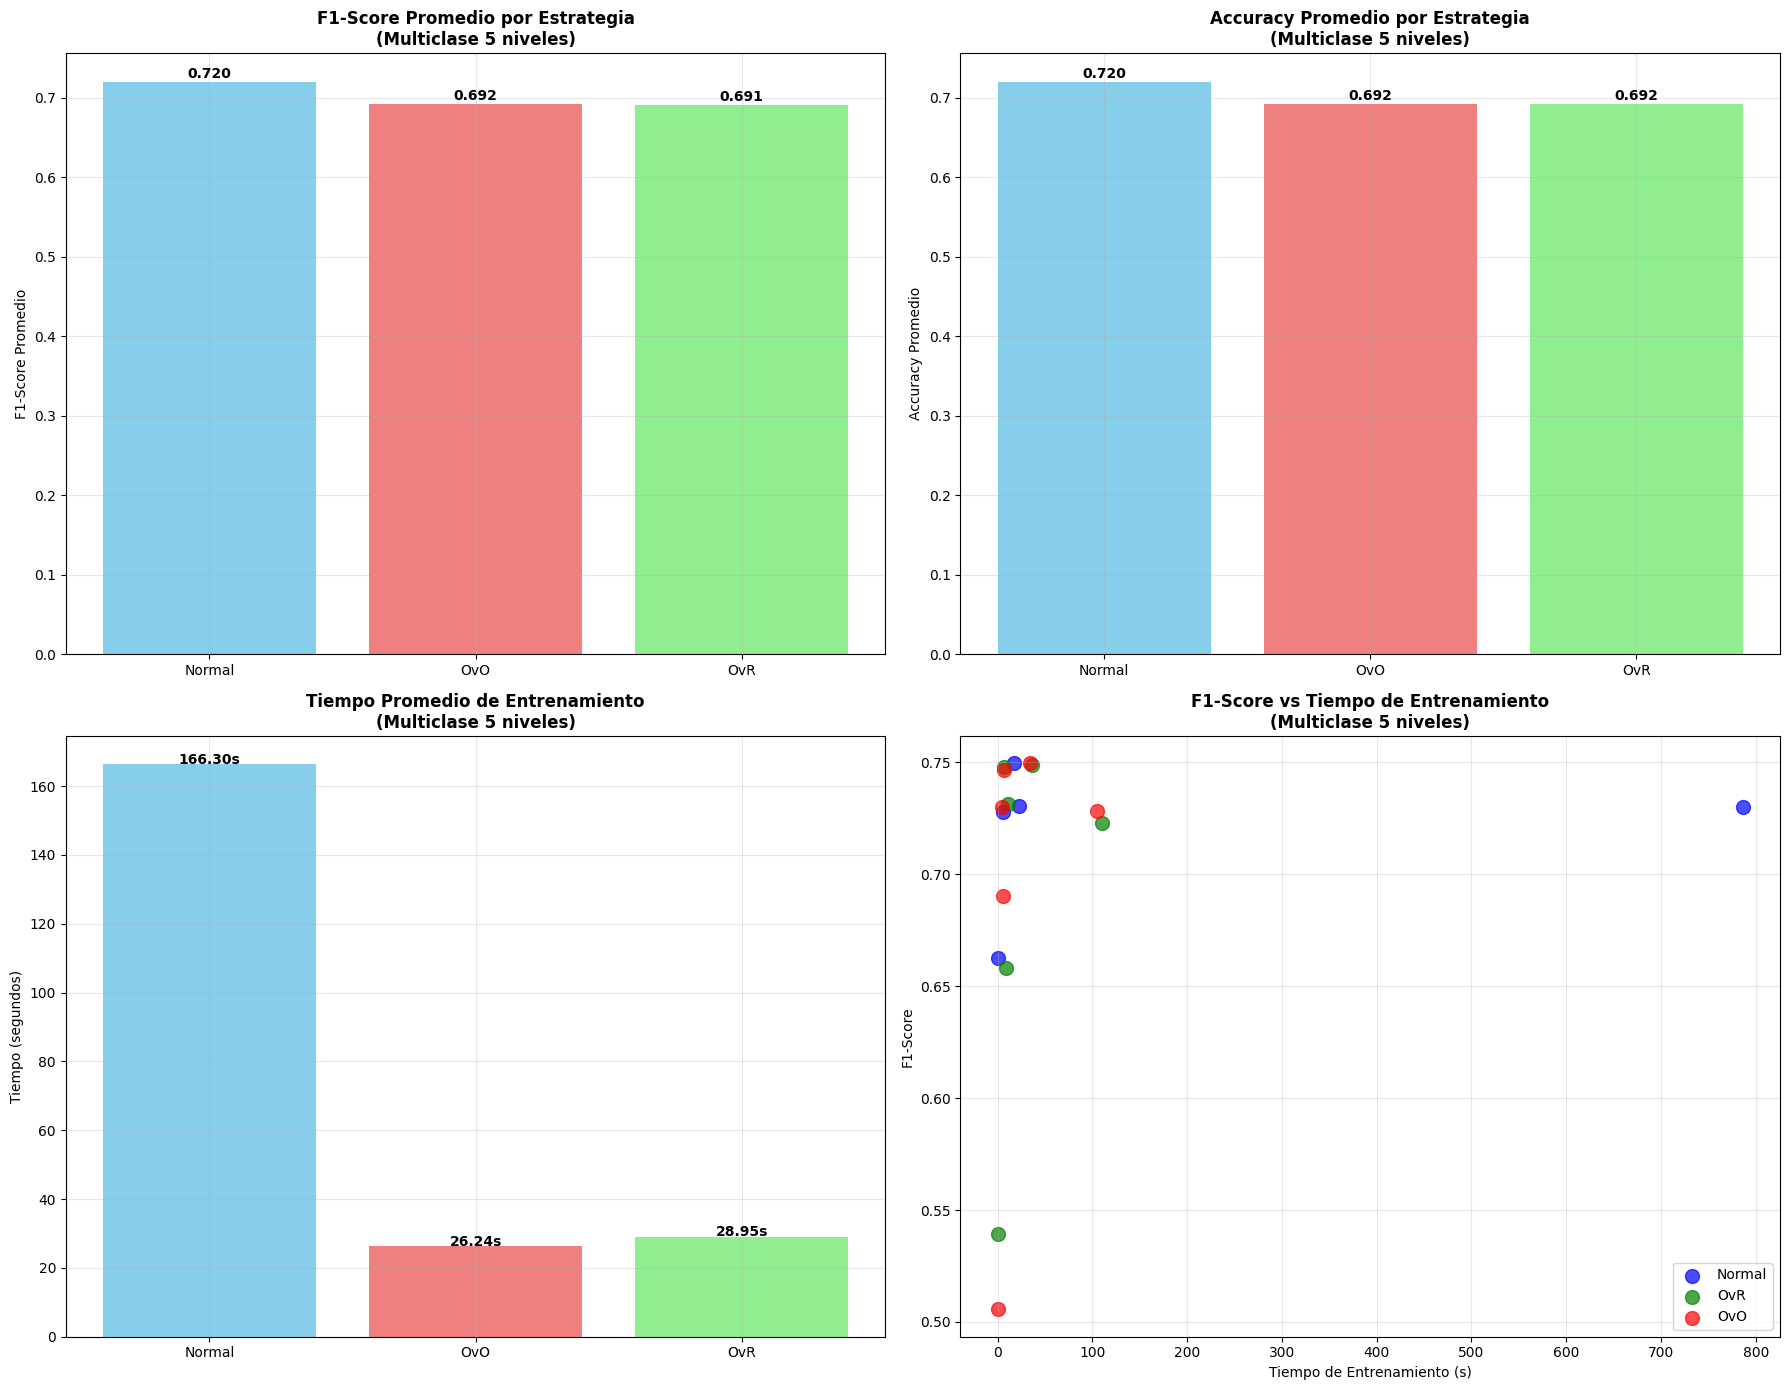

           F1-Score                 Accuracy                  \
               mean     std     max     mean     std     max   
Estrategia                                                     
Normal       0.7201  0.0333  0.7495   0.7200  0.0330  0.7498   
OvO          0.6916  0.0935  0.7494   0.6917  0.0925  0.7494   
OvR          0.6913  0.0817  0.7485   0.6919  0.0812  0.7486   

           Tiempo Entrenamiento            
                           mean       std  
Estrategia                                 
Normal                 166.3019  346.6451  
OvO                     26.2362   40.6231  
OvR                     28.9500   41.4761  
Normal:
   Modelo: Random Forest
   F1-Score: 0.7495
   Accuracy: 0.7498
   Tiempo: 17.76s

OvR:
   Modelo: Random Forest
   F1-Score: 0.7485
   Accuracy: 0.7486
   Tiempo: 36.80s

OvO:
   Modelo: Random Forest
   F1-Score: 0.7494
   Accuracy: 0.7494
   Tiempo: 34.30s


Comparación completada para clasificación multiclase (5 niveles)


In [174]:

all_multi5_results = []

for result in multiclass5_results: 
    all_multi5_results.append({
        'Modelo': result['model_name'],
        'Estrategia': 'Normal',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })


for result in ovr_multi5_results:
    all_multi5_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvR',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
for result in ovo_multi5_results:
    all_multi5_results.append({
        'Modelo': result['model_name'].replace('OvR ', ''),
        'Estrategia': 'OvO',
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy'],
        'Tiempo Entrenamiento': result['training_time']
    })
comparison_multi5_df = pd.DataFrame(all_multi5_results)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

strategy_f1_5 = comparison_multi5_df.groupby('Estrategia')['F1-Score'].mean()
axes[0,0].bar(strategy_f1_5.index, strategy_f1_5.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,0].set_title('F1-Score Promedio por Estrategia\n(Multiclase 5 niveles)', fontweight='bold')
axes[0,0].set_ylabel('F1-Score Promedio')
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_f1_5.values):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_acc_5 = comparison_multi5_df.groupby('Estrategia')['Accuracy'].mean()
axes[0,1].bar(strategy_acc_5.index, strategy_acc_5.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0,1].set_title('Accuracy Promedio por Estrategia\n(Multiclase 5 niveles)', fontweight='bold')
axes[0,1].set_ylabel('Accuracy Promedio')
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(strategy_acc_5.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

strategy_time_5 = comparison_multi5_df.groupby('Estrategia')['Tiempo Entrenamiento'].mean()
axes[1,0].bar(strategy_time_5.index, strategy_time_5.values, 
              color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1,0].set_title('Tiempo Promedio de Entrenamiento\n(Multiclase 5 niveles)', fontweight='bold')
axes[1,0].set_ylabel('Tiempo (segundos)')
axes[1,0].grid(True, alpha=0.3)
for i, v in enumerate(strategy_time_5.values):
    axes[1,0].text(i, v + 0.2, f'{v:.2f}s', ha='center', fontweight='bold')


colors_map = {'Normal': 'blue', 'OvO': 'red', 'OvR': 'green'}
for strategy in comparison_multi5_df['Estrategia'].unique():
    data = comparison_multi5_df[comparison_multi5_df['Estrategia'] == strategy]
    axes[1,1].scatter(data['Tiempo Entrenamiento'], data['F1-Score'], 
                     label=strategy, color=colors_map[strategy], s=100, alpha=0.7)

axes[1,1].set_title('F1-Score vs Tiempo de Entrenamiento\n(Multiclase 5 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo de Entrenamiento (s)')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary_5_levels = comparison_multi5_df.groupby('Estrategia').agg({
    'F1-Score': ['mean', 'std', 'max'],
    'Accuracy': ['mean', 'std', 'max'],
    'Tiempo Entrenamiento': ['mean', 'std']
}).round(4)

print(summary_5_levels)

for strategy in comparison_multi5_df['Estrategia'].unique():
    best_model = comparison_multi5_df[comparison_multi5_df['Estrategia'] == strategy].loc[
        comparison_multi5_df[comparison_multi5_df['Estrategia'] == strategy]['F1-Score'].idxmax()
    ]
    print(f"{strategy}:")
    print(f"   Modelo: {best_model['Modelo']}")
    print(f"   F1-Score: {best_model['F1-Score']:.4f}")
    print(f"   Accuracy: {best_model['Accuracy']:.4f}")
    print(f"   Tiempo: {best_model['Tiempo Entrenamiento']:.2f}s")
    print()

print(f"\nComparación completada para clasificación multiclase (5 niveles)")

In [ ]:
xg = xgboost.XGBClassifier(objective='binary:logistic')
result = evaluate_model(model=xg,
            X_train=X_train_bin,
            X_test=X_test_bin,
            y_train=y_train_bin,
            y_test=y_test_bin,
            model_name=model_name,
            task_type='binary',
            _scaler=scaler)
result

Entrenando Naive Bayes...
   Completado - Accuracy: 0.9057, F1: 0.9046
{'model_name': 'Naive Bayes', 'task_type': 'binary', 'accuracy': 0.9057365151251234, 'precision': 0.8949325894932589, 'recall': 0.9145436189797493, 'f1_score': 0.9046318324668841, 'roc_auc': 0.9739479520385893, 'training_time': 2.172369956970215, 'prediction_time': 0.08714485168457031, 'model_object': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
  

In [172]:
xg_3 = xgboost.XGBClassifier(objective='multi:softmax',eval_metrics = 'mlogloss',num_class=3)
result3 = evaluate_model(model=xg_3,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass',
            _scaler=scaler1)
result3

Entrenando Naive Bayes...
   Completado - Accuracy: 0.8483, F1: 0.8487


{'model_name': 'Naive Bayes',
 'task_type': 'multiclass',
 'accuracy': 0.8483133019799106,
 'precision': 0.851430289689122,
 'recall': 0.8483133019799106,
 'f1_score': 0.848692757535769,
 'roc_auc': None,
 'training_time': 4.5199408531188965,
 'prediction_time': 0.1073758602142334,
 'model_object': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None,
               eval_metrics='mlogloss', feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
 

In [173]:
xg_5 = xgboost.XGBClassifier(objective='multi:softmax',eval_metrics = 'mlogloss',num_class=5)
result5 = evaluate_model( model=xg_5,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass',
            _scaler = scaler2)
result5

Entrenando Naive Bayes...
   Completado - Accuracy: 0.7499, F1: 0.7501


{'model_name': 'Naive Bayes',
 'task_type': 'multiclass',
 'accuracy': 0.7498983916855367,
 'precision': 0.7552910151121325,
 'recall': 0.7498983916855367,
 'f1_score': 0.7500951876806861,
 'roc_auc': None,
 'training_time': 12.431195735931396,
 'prediction_time': 0.14445781707763672,
 'model_object': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None,
               eval_metrics='mlogloss', feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None